# Coloration black-box on **LA2A** — Local Eval

Companion to [`train_lstm_color_blackbox.ipynb`](train_lstm_color_blackbox.ipynb)
(this folder) — the LA2A retarget of the `06_output` coloration black-box. Same
`ColorBlackboxLSTM` model (the unchanged SOTA `LSTM32TVC` trunk fed the
**amplitude-matched** signal instead of the raw dry) and the SAME 9-column
streaming metric engine as [`eval_lstm_gain_prior_ws.ipynb`](eval_lstm_gain_prior_ws.ipynb) /
[`eval_lstm_blackbox_gr.ipynb`](eval_lstm_blackbox_gr.ipynb), so LA2A numbers drop
straight into the cross-model comparison.

```
matched = x · 10^(gr/20)                    ← gain: explicit multiply, obeys
y = tanh( lin( LSTM(matched ⊕ tvcond) ) )   ← coloration: SOTA LSTM32TVC trunk
```

- **Input**: the amplitude-matched signal + the 2 static LA2A knobs
  (`[comp_limit, peak_reduction]` via `tvcond`). **The model never sees the GR
  value itself** — the gain is baked into its input, so any commanded GR
  trajectory (incl. a sidechain-predicted one) is applied exactly.
- **No Δg, no waveshaper, no additive head, no zero-init anchor.** The only
  decomposition is `color = y − matched`, the total learned coloration (the
  `return_parts_full` Δg / waveshaper slots are `≡ 0` for this model).
- **Target**: wet audio. **Stateful inference**: whole-region streaming with
  `reset_states()` at each region start.

Two things differ from the diffssl coloration eval:

- **GR on-the-fly.** Instead of loading `gr_curves/*.pt`, the oracle GR is
  recomputed per segment from `(dry, wet)` with the exact export function
  `src.dsp_torch.gain_reduction_db(·, 1024)` + a 1023-sample lookback —
  bit-identical to the exported curve (see `dataset_la2a`). No `.pt` files needed.
- **Split = temporal regions, not held-out pairs.** LA2A's 84 recordings each hold
  one setting, so the train notebook splits **within each recording**
  (`train[0,.8) / val[.8,.9) / test[.9,1)`). "Validation" / "test" here therefore
  mean the `[.8,.9)` / `[.9,1)` fraction **regions of every recording** — unseen
  audio at known settings. There is no external `test_ground_truth/` set for LA2A.

**§9 runs the GR-source ablation** (`oracle / predicted / const_mean / const_0db /
amp_match`). Unlike the LA2A gain-prior eval, the `predicted` variant **is**
available here: the LA2A blackbox GR predictor
([`train_lstm_blackbox_gr.ipynb`](train_lstm_blackbox_gr.ipynb) → `la2a_gr_pred_runs`)
supplies a wet-free GR curve, which makes `predicted` the **deployable** number
for the full sidechain cascade.

> **Polarity.** The `tanh` readout of this family has learned `−wet` before
> (diffssl color-bb and gr-tfilm runs — see `project_color_bb_polarity`). **§6b
> checks `corr(pred, wet)` before any metric is trusted** and fails loudly if the
> checkpoint is inverted; `NEGATE_READOUT` in ── 5 is the exact fix (`tanh` is odd,
> so flipping `lin.weight` / `lin.bias` negates the output exactly).
>
> The first LA2A coloration run, `la2a_color_bb_20260730_134114_…_b64lr2e3`, **is
> inverted** (corr ≈ −0.998) — set `NEGATE_READOUT = True` when evaluating it.

In [1]:
# ── 0. Imports and defaults ─────────────────────────────────────────

import gc, glob, json, os, sys, types, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

warnings.filterwarnings("ignore", category=UserWarning)

# model_color_lstm imports nablafx's TVFiLMCond. Stub the `rational` /
# `frechet_audio_distance` import-chain deps so `from nablafx...` doesn't drag in
# broken wheels — identical to the train notebook's cell 0.
_rational = types.ModuleType("rational")
_rational.torch = types.ModuleType("rational.torch")
_rational.torch.Rational = type("Rational", (), {})
sys.modules.setdefault("rational", _rational)
sys.modules.setdefault("rational.torch", _rational.torch)
_fad = types.ModuleType("frechet_audio_distance")
_fad.FrechetAudioDistance = type("FrechetAudioDistance", (), {})
sys.modules.setdefault("frechet_audio_distance", _fad)

REPO_ROOT = next(
    (p for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents] if (p / "pyproject.toml").is_file()),
    Path.cwd().resolve(),
)
sys.path.insert(0, str(REPO_ROOT))                        # `src`
sys.path.insert(0, str(REPO_ROOT / "nablafx"))            # raw ./nablafx/ clone (TVFiLMCond)
sys.path.insert(0, str(REPO_ROOT / "06_output"))          # model_color_lstm, amplitude_match, system_gainprior
sys.path.insert(0, str(REPO_ROOT / "08_la2a"))            # dataset_la2a, splits_la2a
sys.path.insert(0, str(REPO_ROOT / "03_initial_GR_pred")) # eval_helpers
# 05_conditioning holds the LA2A GR predictor (model_blackbox_gr) used by the §9
# `predicted` ablation. APPEND, never insert: its model.py / splits.py /
# dataset.py / system.py would otherwise shadow 06_output's same-named modules.
sys.path.append(str(REPO_ROOT / "05_conditioning"))

from amplitude_match import GR_DB_MIN, GR_DB_MAX, amplitude_match
from model_color_lstm import ColorBlackboxLSTM
from system_gainprior import esr_metric
from splits_la2a import (
    La2aSplitManifest, LA2A_PARAM_ORDER, normalize_la2a_params, region_bounds,
)
from dataset_la2a import discover_la2a_pairs, RMS_WINDOW, SAMPLE_RATE
from eval_helpers import (
    _checkpoint_sort_key, _find_hparams_json, _read_dry_wet_segment,
    _weighted_average_metric_rows, latest_best_checkpoint, list_runs, plot_loss_curves,
)
from src.dsp_torch import gain_reduction_db

DATA_ROOT = "/Volumes/Saola's Drive/AllCode/thesis/data/LA2A"
RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/la2a_gain_prior_runs"
GR_PRED_RUNS_DIR = "/Volumes/Saola's Drive/AllCode/thesis/data/la2a_gr_pred_runs"
DEVICE = "cpu"

print(f"torch {torch.__version__}  |  device: {DEVICE}")
print(f"GR clamp: [{GR_DB_MIN}, {GR_DB_MAX}] dB  |  RMS window: {RMS_WINDOW} samples")

/Volumes/Saola's Drive/AllCode/thesis/Virtual-Analogue-Compressor-Modelling/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


torch 2.10.0  |  device: cpu
GR clamp: [-30.0, 5.0] dB  |  RMS window: 1024 samples


In [2]:
# ── 1. List available coloration black-box runs ──────────────────────

MODEL_TYPE = "ColorBlackboxLSTM"   # hparams["model_type"]

runs_df = list_runs(RUNS_DIR)
assert not runs_df.empty, f"No runs in {RUNS_DIR}"
available_models_df = runs_df[runs_df["type"] == MODEL_TYPE].copy()
if available_models_df.empty:
    # fall back to folder-name tag if hparams["model_type"] is missing/older
    available_models_df = runs_df[runs_df["run"].str.contains("color_bb", case=False, na=False)].copy()
assert not available_models_df.empty, (
    f"No '{MODEL_TYPE}' runs in {RUNS_DIR} — train with train_lstm_color_blackbox.ipynb first."
)

display_cols = ["run", "type", "epoch", "best_val", "n_ckpts", "eval_ckpt", "modified"]
print(f"Available coloration black-box runs: {len(available_models_df)}")
display(available_models_df[display_cols])

Available coloration black-box runs: 1


,run,type,epoch,best_val,n_ckpts,eval_ckpt,modified
1,la2a_color_bb_20260730_134114_la2a_lstm32_colo...,ColorBlackboxLSTM,100,0.496755,4,best-093-87420.ckpt,2026-08-02 08:41:24.489203930


In [3]:
# ── 2. Select run, checkpoint and split manifest ─────────────────────

# Leave as None to auto-pick the most recently modified matching run.
SELECTED_RUN_NAME: str | None = None

if not SELECTED_RUN_NAME:
    selected_run = available_models_df.iloc[-1]   # list_runs sorts by mtime asc
else:
    matches = available_models_df[available_models_df["run"] == SELECTED_RUN_NAME]
    assert len(matches) == 1, f"Run not found: {SELECTED_RUN_NAME}"
    selected_run = matches.iloc[0]

RUN_NAME = str(selected_run["run"])
RUN_DIR = os.path.join(RUNS_DIR, RUN_NAME)
CKPT_DIR = os.path.join(RUN_DIR, "checkpoints")
HPARAMS_PATH = os.path.join(RUN_DIR, "hparams.json")
EVAL_CKPT_PATH = latest_best_checkpoint(RUN_DIR)

with open(HPARAMS_PATH) as f:
    HP = json.load(f)
SPLIT = La2aSplitManifest.load(os.path.join(RUN_DIR, "split_manifest.json"))
TRAIN_FRAC, VAL_FRAC, TEST_FRAC = SPLIT.train_frac, SPLIT.val_frac, SPLIT.test_frac

# LA2A split is temporal WITHIN each recording (every setting in every split), so
# "val"/"test" are the [.8,.9)/[.9,1) fraction REGIONS of all recordings, not
# held-out (song, setting) pairs. Discover recordings (paths+frames) and match to
# the manifest inventory by id.
RECS = discover_la2a_pairs(DATA_ROOT)
REC_BY_ID = {r["id"]: r for r in RECS}
_man_ids = {p["id"] for p in SPLIT.pairs}
_missing = _man_ids - set(REC_BY_ID)
assert not _missing, f"{len(_missing)} manifest recordings missing on disk: {sorted(_missing)}"
EVAL_RECS = [REC_BY_ID[p["id"]] for p in sorted(SPLIT.pairs, key=lambda q: q["id"])]


def _region(rec, split):
    return region_bounds(rec["frames"], TRAIN_FRAC, VAL_FRAC, TEST_FRAC)[split]


def _split_seconds(split):
    return sum(_region(r, split)[1] - _region(r, split)[0] for r in EVAL_RECS) / int(HP["sample_rate"])


print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
if pd.notna(selected_run.get("best_val")):
    print(f"Best val loss  : {selected_run['best_val']:.6f}")
print(f"Recordings     : {len(EVAL_RECS)}  ({len(SPLIT.settings)} unique [comp_limit, peak_reduction])")
print(f"Split policy   : temporal within recording — "
      f"train[0,{TRAIN_FRAC}) val[{TRAIN_FRAC},{round(TRAIN_FRAC+VAL_FRAC,3)}) "
      f"test[{round(TRAIN_FRAC+VAL_FRAC,3)},1)")
print(f"Val  regions   : {_split_seconds('val')/60:.1f} min total (unseen audio, known settings)")
print(f"Test regions   : {_split_seconds('test')/60:.1f} min total")

Selected run   : la2a_color_bb_20260730_134114_la2a_lstm32_color_bb_b64lr2e3
Eval checkpoint: best-093-87420.ckpt
Best val loss  : 0.496755
Recordings     : 84  (42 unique [comp_limit, peak_reduction])
Split policy   : temporal within recording — train[0,0.8) val[0.8,0.9) test[0.9,1)
Val  regions   : 145.9 min total (unseen audio, known settings)
Test regions   : 145.9 min total


In [4]:
# ── 3. Inspect checkpoints ──────────────────────────────────────────

print(f"Selected run   : {RUN_NAME}")
print(f"Eval checkpoint: {os.path.basename(EVAL_CKPT_PATH)}")
print("Checkpoints    :")
for c in sorted(glob.glob(os.path.join(CKPT_DIR, "*.ckpt")), key=_checkpoint_sort_key):
    marker = " <-- eval" if os.path.abspath(c) == os.path.abspath(EVAL_CKPT_PATH) else ""
    sz = os.path.getsize(c) / 1e6
    print(f"  {os.path.basename(c):<36}  {sz:6.2f} MB{marker}")

Selected run   : la2a_color_bb_20260730_134114_la2a_lstm32_color_bb_b64lr2e3
Eval checkpoint: best-093-87420.ckpt
Checkpoints    :
  last.ckpt                               0.11 MB
  best-087-81840.ckpt                     0.11 MB
  best-089-83700.ckpt                     0.11 MB
  best-093-87420.ckpt                     0.11 MB <-- eval


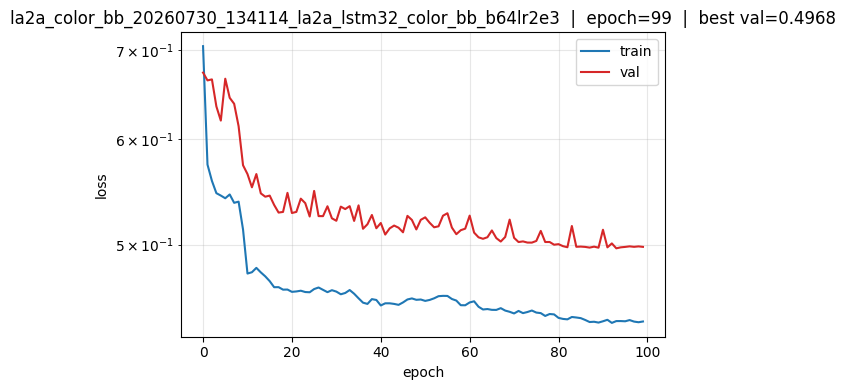

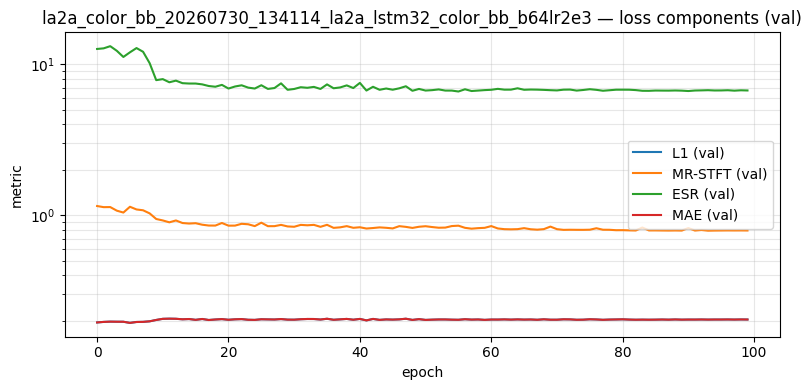

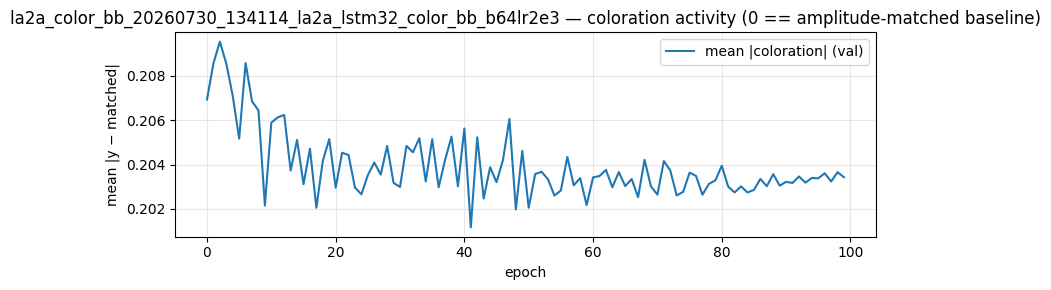

In [5]:
# ── 4. Loss curves (total + components + coloration activity) ────────

_ = plot_loss_curves(RUN_DIR)

csv_path = Path(RUN_DIR) / "csv" / "metrics.csv"
if csv_path.exists():
    _df = pd.read_csv(csv_path)

    comp_cols = [
        ("loss/val_td", "L1 (val)"),
        ("loss/val_fd", "MR-STFT (val)"),
        ("esr/val", "ESR (val)"),
        ("mae/val", "MAE (val)"),
    ]
    if any(c in _df.columns for c, _ in comp_cols):
        fig, ax = plt.subplots(figsize=(8, 4))
        for col, label in comp_cols:
            if col in _df.columns:
                rows = _df.dropna(subset=[col])[["epoch", col]]
                if len(rows):
                    ax.plot(rows["epoch"], rows[col], label=label, lw=1.5)
        ax.set_xlabel("epoch"); ax.set_ylabel("metric"); ax.set_yscale("log")
        ax.grid(alpha=0.3, which="both"); ax.legend()
        ax.set_title(f"{RUN_NAME} — loss components (val)")
        plt.tight_layout(); plt.show()

    # coloration activity: mean |y − matched|, the total learned coloration on top
    # of the pure amplitude-match multiply. (Δg is ≡ 0 for this model — no gain
    # head — so gain/val_delta_db is a flat 0 and is not plotted.)
    if "gain/val_color" in _df.columns:
        fig, ax = plt.subplots(figsize=(8, 3))
        rows = _df.dropna(subset=["gain/val_color"])[["epoch", "gain/val_color"]]
        if len(rows):
            ax.plot(rows["epoch"], rows["gain/val_color"], lw=1.5, color="#1f77b4",
                    label="mean |coloration| (val)")
        ax.set_xlabel("epoch"); ax.set_ylabel("mean |y − matched|"); ax.grid(alpha=0.3)
        ax.legend(loc="best")
        ax.set_title(f"{RUN_NAME} — coloration activity (0 == amplitude-matched baseline)")
        plt.tight_layout(); plt.show()

In [11]:
# ── 5. Checkpoint loading (ColorBlackboxLSTM) ────────────────────────
# NEGATE_READOUT is the polarity escape hatch (see §6b and
# project_color_bb_polarity): this family's tanh readout sometimes converges on
# −wet. tanh is odd, so negating lin.weight/lin.bias negates the output EXACTLY —
# flipping it here reproduces the '_signfix' run-dir trick without rewriting the
# checkpoint. Set True ONLY when §6b reports a strongly NEGATIVE corr(pred, wet),
# then re-run this cell and §6b (which must then come out positive).

NEGATE_READOUT = True


def load_model_from_ckpt(ckpt_path, hparams_path=None):
    # Build from hparams.json and load weights (strip Lightning 'model.' prefix).
    hparams_path = hparams_path or _find_hparams_json(ckpt_path)
    with open(hparams_path) as f:
        hp = json.load(f)
    assert hp.get("model_type") == MODEL_TYPE, hp.get("model_type")
    m = hp["model"]
    model = ColorBlackboxLSTM(
        num_controls=int(m["num_controls"]),
        hidden_size=int(m["hidden_size"]),
        num_layers=int(m["num_layers"]),
        tvcond_dim=int(m.get("tvcond_dim", 16)),
        cond_block_size=int(m.get("cond_block_size", 128)),
        cond_num_layers=int(m.get("cond_num_layers", 1)),
    )
    sd = torch.load(ckpt_path, map_location=DEVICE, weights_only=False)["state_dict"]
    model.load_state_dict({k[len("model."):]: v for k, v in sd.items() if k.startswith("model.")})
    if NEGATE_READOUT:
        with torch.no_grad():
            model.lin.weight.neg_()
            model.lin.bias.neg_()
        print("NEGATE_READOUT=True — readout sign flipped, y := −y (exact: tanh is odd).")
    model.to(DEVICE).eval()
    n_params = sum(p.numel() for p in model.parameters())
    print(
        f"Loaded {n_params:,}-param ColorBlackboxLSTM  "
        f"(hidden={model.hidden_size}, controls={model.num_controls}, "
        f"cond_block={model.cond_block_size})"
    )
    return model, hp


MODEL, HP = load_model_from_ckpt(EVAL_CKPT_PATH, HPARAMS_PATH)
SR = int(HP["sample_rate"])
SAMPLE_LENGTH = int(HP.get("sample_length", 132300))
# GR derived from waveforms uses the same 1024-sample causal RMS window the
# exported gr_curves were built with (== dataset_la2a on-the-fly GR).
RMS_WIN = int(HP.get("rms_window", RMS_WINDOW))

NEGATE_READOUT=True — readout sign flipped, y := −y (exact: tanh is odd).
Loaded 7,905-param ColorBlackboxLSTM  (hidden=32, controls=2, cond_block=128)


In [12]:
# ── 6. Prediction & visualisation (stateful, coloration black-box) ────
# LA2A data access: paths by recording id, static knobs [comp_limit, peak_reduction],
# and GR recomputed ON-THE-FLY from (dry, wet) with the exact export function
# (causal 1024-RMS + 1023-sample lookback == the exported .pt). The model forms
# matched = dry·10^(gr/20) internally; a pre_roll_sec context warms the LSTM +
# tvcond states before the scored segment.
#
# Besides the waveform we recover a gain-reduction curve from the prediction
# (GR_pred = RMS_dB(pred) − RMS_dB(dry), the GR-bins definition) AND expose the
# model's own coloration: color = y − matched (the full residual the trunk adds on
# top of the pure multiply). matched = pred − color is the amplitude-match
# baseline (Δg / waveshaper are ≡ 0 for this model).

DEFAULT_PRE_ROLL_SEC = 10.0
LOOKBACK = RMS_WIN - 1


def _params_for(rec) -> torch.Tensor:
    # Normalised static knobs [1, 2] from one recording's setting.
    return torch.tensor(
        normalize_la2a_params(rec["comp_limit"], rec["peak_reduction"]),
        dtype=torch.float32, device=DEVICE,
    ).unsqueeze(0)


def _read_seg_with_gr(rec, start: int, stop: int):
    # dry, gr, wet for [start, stop) as [1, n] tensors. GR recomputed on-the-fly
    # with a 1023-sample lookback so the causal window is filled from real samples
    # (bit-identical to slicing the exported .pt).
    read_start = max(0, start - LOOKBACK)
    dry, wet = _read_dry_wet_segment(rec["dry"], rec["wet"], read_start, stop, SR)
    n = min(dry.shape[-1], wet.shape[-1])
    dry, wet = dry[..., :n], wet[..., :n]
    gr = gain_reduction_db(dry, wet, RMS_WIN)
    drop = start - read_start
    return dry[..., drop:], gr[..., drop:], wet[..., drop:]


def _gr_from_audio(dry: torch.Tensor, sig: torch.Tensor) -> np.ndarray:
    # GR (dB) of `sig` relative to `dry`, clamped to the GR range (GR-bins definition).
    return gain_reduction_db(dry, sig, RMS_WIN).clamp(GR_DB_MIN, GR_DB_MAX).squeeze().cpu().numpy()


def _default_test_segment_sec(rec) -> float:
    # A segment start inside the recording's TEST region (region start + 30 s, clamped).
    r0, r1 = _region(rec, "test")
    start = min(r0 + int(30 * SR), max(r0, r1 - int(6 * SR)))
    return start / SR


@torch.no_grad()
def predict_wet_segment(rec, start_sec, duration_sec=6.0,
                        pre_roll_sec=DEFAULT_PRE_ROLL_SEC, model=None):
    model = model or MODEL
    if isinstance(rec, int):
        rec = REC_BY_ID[rec]
    start = int(round(start_sec * SR))
    stop = start + int(round(duration_sec * SR))
    context_start = max(0, start - int(round(pre_roll_sec * SR)))
    offset = start - context_start

    dry_ctx, gr_ctx, wet_ctx = _read_seg_with_gr(rec, context_start, stop)
    params = _params_for(rec)

    model.reset_states()
    pred_full, _delta_full, color_full, _ws_full = model(
        dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE), params,
        return_parts_full=True)

    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    color = color_full[..., sl].squeeze(0).cpu()
    matched = pred - color                          # the amp-match baseline (Δg ≡ 0)
    wet = wet_ctx[..., sl].cpu()
    dry = dry_ctx[..., sl].cpu()
    gr_in = gr_ctx[..., sl].cpu()
    err = (pred - wet).squeeze().numpy()

    gr_true = _gr_from_audio(dry, wet)
    gr_pred = _gr_from_audio(dry, pred)
    gr_err = gr_pred - gr_true

    t_len = pred.shape[-1]
    return {
        "id": rec["id"], "comp_limit": rec["comp_limit"], "peak_reduction": rec["peak_reduction"],
        "label": f"id {rec['id']} · cl={rec['comp_limit']} pr={rec['peak_reduction']}",
        "sample_rate": SR, "start_sec": start_sec, "duration_sec": t_len / SR,
        "pre_roll_sec": offset / SR, "time": np.arange(t_len) / SR,
        "dry": dry.squeeze().numpy(), "wet": wet.squeeze().numpy(), "pred": pred.squeeze().numpy(),
        "matched": matched.squeeze().numpy(), "color": color.squeeze().numpy(),
        "error": err, "gr_in": gr_in.squeeze().numpy(),
        "gr_true": gr_true, "gr_pred": gr_pred, "gr_error": gr_err,
        "mae": float(np.mean(np.abs(err))),
        "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
        "gr_mae_db": float(np.mean(np.abs(gr_err))),
        "gr_rmse_db": float(np.sqrt(np.mean(gr_err ** 2))),
        "color_mae": float(np.mean(np.abs(color.numpy()))),
    }


def visualize_prediction(rec=None, start_sec=None, duration_sec=6.0,
                         pre_roll_sec=DEFAULT_PRE_ROLL_SEC, title=None):
    rec = EVAL_RECS[0] if rec is None else (REC_BY_ID[rec] if isinstance(rec, int) else rec)
    start_sec = _default_test_segment_sec(rec) if start_sec is None else start_sec
    seg = predict_wet_segment(rec, start_sec, duration_sec, pre_roll_sec)

    t = seg["time"]
    # rows: dry | waveform (wet/pred/matched) | wave err + coloration | GR (true/pred) | GR err
    fig, axes = plt.subplots(5, 1, figsize=(11, 13), sharex=True,
                             gridspec_kw={"height_ratios": [1, 2, 1, 2, 1]})

    axes[0].plot(t, seg["dry"], lw=0.6, color="#444")
    axes[0].set_ylabel("dry"); axes[0].set_ylim(-1.05, 1.05); axes[0].grid(alpha=0.3)

    axes[1].plot(t, seg["wet"], label="target (wet)", lw=1.0, color="#1f77b4")
    axes[1].plot(t, seg["pred"], label="prediction", lw=0.9, color="#d62728", alpha=0.85)
    axes[1].plot(t, seg["matched"], label="matched (x·10^(gr/20))", lw=0.6,
                 color="#7f7f7f", alpha=0.6)
    axes[1].set_ylabel("amp"); axes[1].legend(loc="lower right"); axes[1].set_ylim(-1.05, 1.05)
    axes[1].grid(alpha=0.3)

    # waveform error, with the learned coloration (pred − matched) overlaid — the
    # residual the SOTA trunk synthesises on top of the pure gain multiply.
    axes[2].plot(t, seg["error"], lw=0.8, color="#2ca02c", label="wave err")
    axes[2].plot(t, seg["color"], lw=0.7, color="#d62728", alpha=0.6,
                 label="coloration (pred − matched)")
    axes[2].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[2].set_ylabel("residual"); axes[2].legend(loc="lower right", fontsize=8)
    axes[2].grid(alpha=0.3)

    axes[3].plot(t, seg["gr_true"], label="target", lw=1.4, color="#1f77b4")
    axes[3].plot(t, seg["gr_pred"], label="prediction", lw=1.2, color="#d62728", alpha=0.85)
    axes[3].plot(t, np.clip(seg["gr_in"], GR_DB_MIN, GR_DB_MAX), lw=0.9, ls="--",
                 color="#7f7f7f", alpha=0.8, label="GR input (applied verbatim)")
    axes[3].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[3].set_ylabel("GR (dB)"); axes[3].legend(loc="lower right"); axes[3].grid(alpha=0.3)

    axes[4].plot(t, seg["gr_error"], lw=0.8, color="#9467bd")
    axes[4].axhline(0, color="k", lw=0.5, alpha=0.4)
    axes[4].set_ylabel("GR err (dB)"); axes[4].set_xlabel("time (s)"); axes[4].grid(alpha=0.3)

    fig.suptitle(title or (
        f"{seg['label']}   (TEST region, {seg['start_sec']:.0f}s)\n"
        f"pre-roll={seg['pre_roll_sec']:.1f}s  MAE {seg['mae']:.4f}  ESR {seg['esr']:.4f}  "
        f"GR MAE={seg['gr_mae_db']:.2f} dB  GR RMSE={seg['gr_rmse_db']:.2f} dB  "
        f"mean|color|={seg['color_mae']:.5f}"
    ), fontsize=10)
    plt.tight_layout(); plt.show()
    return seg

In [13]:
# ── 6b. POLARITY CHECK — run this BEFORE trusting any metric ─────────
# The tanh readout of this family has converged on −wet before (diffssl color-bb
# 20260707_194358 and the gr_tfilm 20260708 run — see project_color_bb_polarity):
# corr(pred, wet) ≈ −0.999, td frozen, fd falling, every waveform metric
# meaningless. Check three recordings spread across the corpus on 20 s TEST-region
# segments; a healthy checkpoint is strongly POSITIVE on all of them.

_pol_recs = [EVAL_RECS[0], EVAL_RECS[len(EVAL_RECS) // 2], EVAL_RECS[-1]]
_pol_corrs = []
for _r in _pol_recs:
    _s = predict_wet_segment(_r, _default_test_segment_sec(_r), duration_sec=20.0)
    _p, _w = torch.from_numpy(_s["pred"]), torch.from_numpy(_s["wet"])
    _c = float((_p * _w).sum() / (_p.norm() * _w.norm() + 1e-12))
    _pol_corrs.append(_c)
    print(f"corr(pred, wet) = {_c:+.4f}   {_s['label']}   "
          f"(MAE {_s['mae']:.4f}, ESR {_s['esr']:.4f})")

_pol_min = min(_pol_corrs)
assert _pol_min > 0.5, (
    f"POLARITY INVERSION suspected (min corr={_pol_min:+.4f}): the readout has "
    "likely learned −wet. Do NOT trust any metric below. Fix: set "
    "NEGATE_READOUT = True in ── 5, re-run ── 5 and this cell (corr must flip "
    "positive) — or export a '_signfix' run dir with the negated readout so "
    "downstream comparisons pick it up. See project_color_bb_polarity."
)
print(f"\nOK: polarity healthy (min corr {_pol_min:+.4f}) — metrics below are meaningful.")
del _pol_recs, _pol_corrs

corr(pred, wet) = +0.9984   id 138 · cl=0 pr=0   (MAE 0.0021, ESR 0.0749)
corr(pred, wet) = +0.9648   id 221 · cl=1 pr=100   (MAE 0.0034, ESR 0.3413)
corr(pred, wet) = +0.9216   id 263 · cl=1 pr=100   (MAE 0.0092, ESR 1.7222)

OK: polarity healthy (min corr +0.9216) — metrics below are meaningful.


## Usage

Re-run the cells below any time; they read the latest synced run outputs from Drive.
Use the available-runs cell first, then set `SELECTED_RUN_NAME` in the selection cell.

- `visualize_prediction(rec=...)` — any recording (an id, or a rec dict); defaults to
  the first recording and a 6 s segment inside its **test** region. Shows the waveform
  (target / prediction / the amplitude-matched baseline the model starts from), the
  **learned coloration** `pred − matched` (the residual the SOTA trunk synthesises on
  top of the pure gain multiply), and the GR curve recovered from the prediction
  against the GR that was fed in.
- `pr_sweep(comp_limit=0)` — test-region segments across a spread of Peak-Reduction
  values (LA2A analog of the diffssl settings sweep; each pr is a **different**
  recording, so the audio differs). Table adds `mean |color|`.
- `coloration_spectra(rec=...)` is the reason this model exists: it overlays the PSDs
  of the *target* coloration (`wet − matched`) and the *learned* coloration
  (`pred − matched`). Overlap is the win condition — but on LA2A read **trends, not
  absolute floors** (part of the low-`pr` residual is the capture-session level
  mismatch, `project_la2a_session_mismatch`).
- The split-metrics cells stream every recording's **val** / **test** region on the
  canonical 9-column engine (ported from `06_output/eval_lstm_gain_prior_ws.ipynb`) —
  results duration-weighted and CSV-saved next to the checkpoint. **── 7** scores the
  validation regions, **── 8** the held-out test regions.
- **§9** runs the GR-source ablation (`oracle / predicted / const_mean / const_0db /
  amp_match`) on a few test regions. Since gain enters only through the input
  multiply, this measures how sensitive the coloration trunk is to the GR trajectory
  it is handed; `predicted` (LA2A blackbox GR predictor) is the **deployable**,
  wet-free number and `amp_match` the no-NN baseline the trunk must beat.
- **§10** prints the val → test summary and the ablation table side by side.

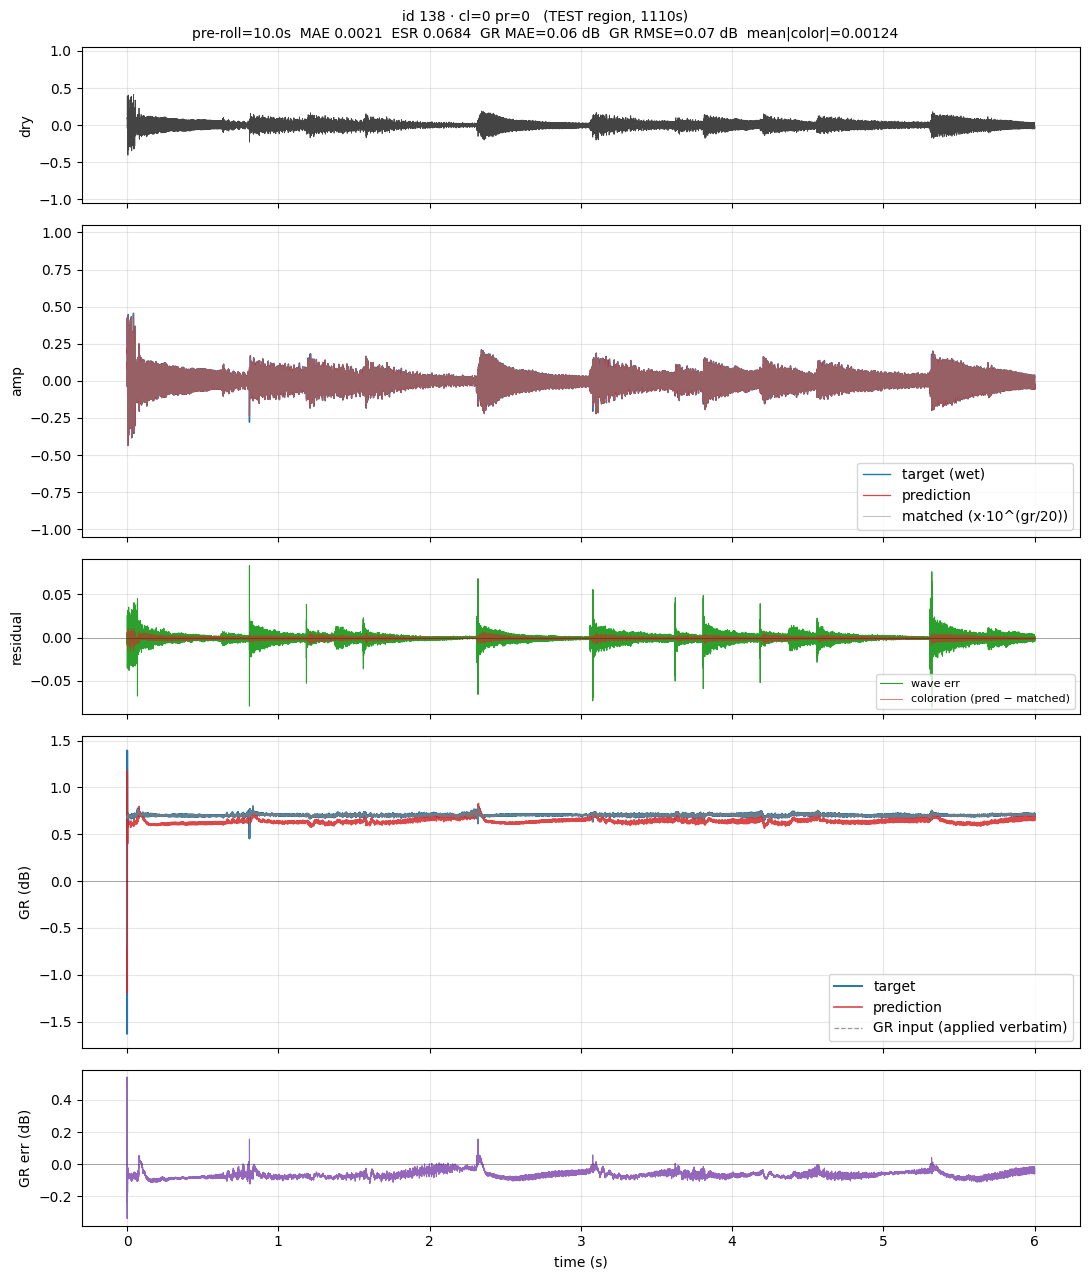

In [14]:
# Single prediction preview — a 6 s segment inside the TEST region of one recording
_ = visualize_prediction(rec=EVAL_RECS[0], duration_sec=6.0)

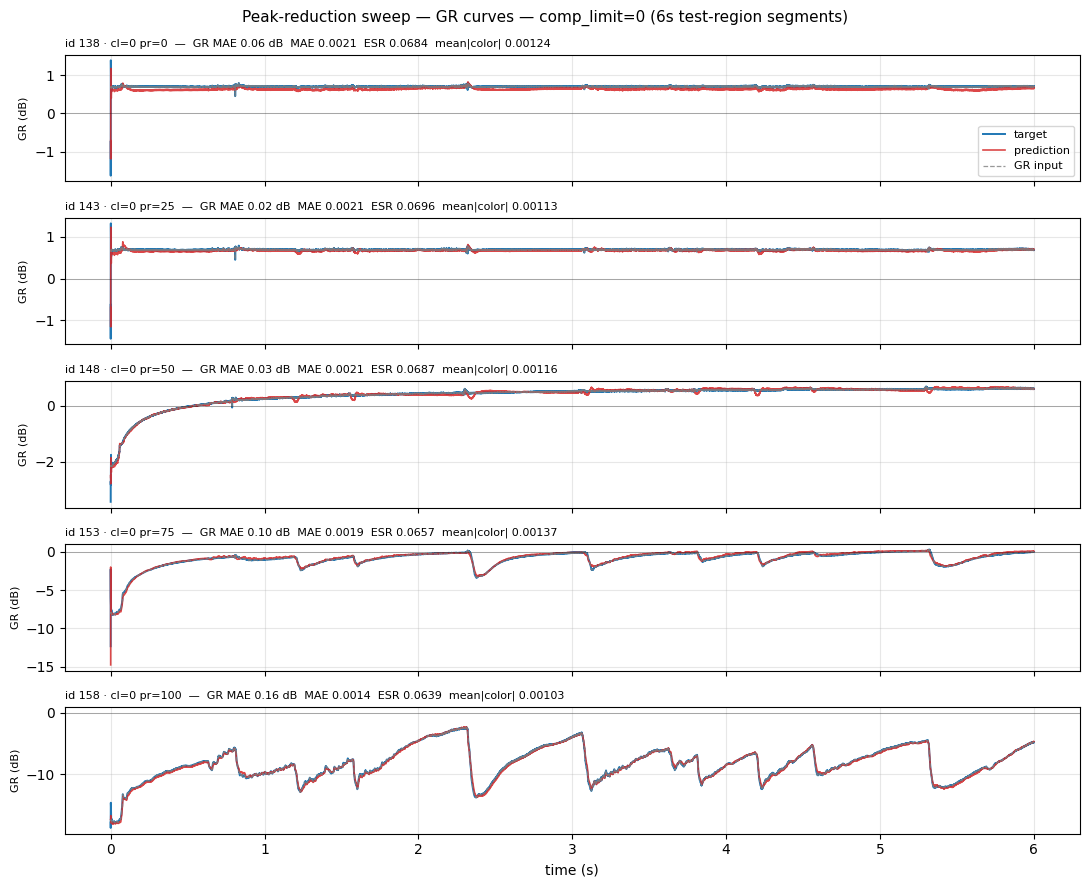

,id,comp_limit,peak_reduction,GR MAE (dB),MAE,ESR,mean |color|
0,138,0,0,0.064730,0.002135,0.068394,0.001236
1,143,0,25,0.021347,0.002115,0.069622,0.001133
2,148,0,50,0.033751,0.002062,0.068672,0.001161
3,153,0,75,0.104849,0.001937,0.065745,0.001366
4,158,0,100,0.159232,0.001384,0.063896,0.001032


In [15]:
# ── Peak-reduction sweep (LA2A analog of settings_sweep) ─────────────
# Each LA2A setting is a DIFFERENT recording (different audio), so this shows the
# model tracking increasing compression across recordings — not one song
# reprocessed. Picks comp_limit=SWEEP_CL and a spread of Peak-Reduction values,
# each on a 6 s segment inside its own test region.

SWEEP_CL = 0


def pr_sweep(comp_limit=SWEEP_CL, pr_values=(0, 25, 50, 75, 100),
             duration_sec=6.0, pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    recs = []
    for pr in pr_values:
        cand = [r for r in EVAL_RECS if r["comp_limit"] == comp_limit and r["peak_reduction"] == pr]
        if cand:
            recs.append(cand[0])
    segs = [predict_wet_segment(r, _default_test_segment_sec(r), duration_sec, pre_roll_sec)
            for r in recs]

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.plot(s["time"], np.clip(s["gr_in"], GR_DB_MIN, GR_DB_MAX), lw=0.9, ls="--",
                color="#7f7f7f", alpha=0.8, label="GR input")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(
            f"{s['label']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
            f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}  mean|color| {s['color_mae']:.5f}",
            fontsize=8, loc="left")
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"Peak-reduction sweep — GR curves — comp_limit={comp_limit} "
                 f"({duration_sec:.0f}s test-region segments)", fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"id": s["id"], "comp_limit": s["comp_limit"], "peak_reduction": s["peak_reduction"],
         "GR MAE (dB)": s["gr_mae_db"], "MAE": s["mae"], "ESR": s["esr"],
         "mean |color|": s["color_mae"]}
        for s in segs
    ])
    display(df)
    return segs, df


sweep_segs, sweep_df = pr_sweep()

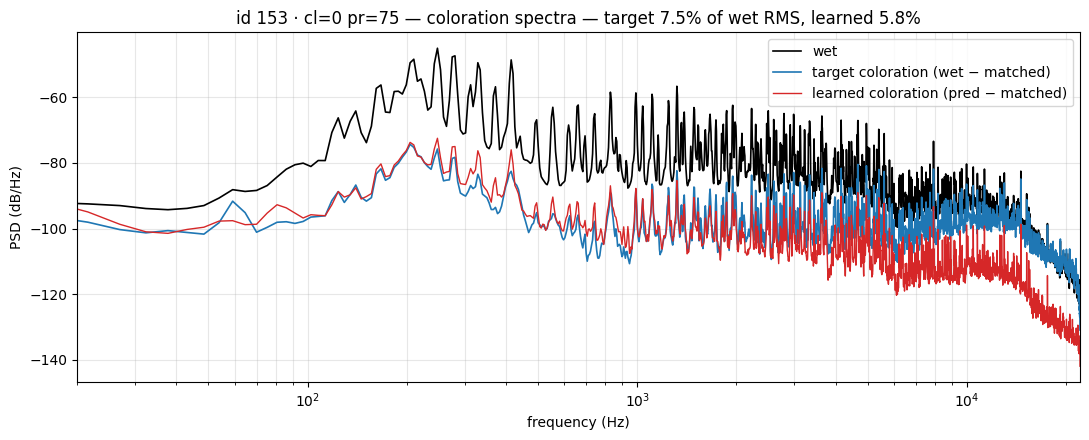

In [16]:
# ── 6c. Learned coloration spectra — the reason this model exists ─────
# The gain-prior runs left the matched→wet residual untouched; this model hands
# that residual to the SOTA trunk. Compare PSDs of the TARGET coloration
# (wet − matched) and the LEARNED coloration (pred − matched == color) on a
# test-region segment. Overlap is the win condition; the RMS shares report each
# coloration's magnitude relative to the wet signal.
#
# LA2A caveat: part of the residual — especially at low peak_reduction, where
# little compression happens — is the capture-session level mismatch, not
# device colour (project_la2a_session_mismatch). Read trends across pr, not the
# absolute floor.

from scipy.signal import welch


def coloration_spectra(rec=None, start_sec=None, duration_sec=6.0,
                       pre_roll_sec=DEFAULT_PRE_ROLL_SEC, nperseg=8192):
    rec = EVAL_RECS[0] if rec is None else (REC_BY_ID[rec] if isinstance(rec, int) else rec)
    start_sec = _default_test_segment_sec(rec) if start_sec is None else start_sec
    seg = predict_wet_segment(rec, start_sec, duration_sec, pre_roll_sec)

    wet = seg["wet"]
    tgt_col = wet - seg["matched"]
    lrn_col = seg["color"]                          # == pred − matched

    fig, ax = plt.subplots(figsize=(11, 4.5))
    for sig, name, style in ((wet, "wet", dict(color="k", lw=1.2)),
                             (tgt_col, "target coloration (wet − matched)",
                              dict(color="#1f77b4", lw=1.2)),
                             (lrn_col, "learned coloration (pred − matched)",
                              dict(color="#d62728", lw=1.0))):
        f, Pxx = welch(sig, fs=SR, nperseg=min(nperseg, len(sig)))
        ax.semilogx(f, 10 * np.log10(Pxx + 1e-18), label=name, **style)
    rms = lambda v: float(np.sqrt(np.mean(v ** 2)))
    ax.set_xlabel("frequency (Hz)"); ax.set_ylabel("PSD (dB/Hz)")
    ax.set_title(f"{seg['label']} — coloration spectra — "
                 f"target {rms(tgt_col) / rms(wet):.1%} of wet RMS, "
                 f"learned {rms(lrn_col) / rms(wet):.1%}")
    ax.grid(alpha=0.3, which="both"); ax.legend(); ax.set_xlim(20, SR / 2)
    plt.tight_layout(); plt.show()
    return seg


# A high-pr recording (real compression → the coloration is device colour, not
# session mismatch), falling back to the first recording.
_col_rec = next((r for r in EVAL_RECS if r["comp_limit"] == 0 and r["peak_reduction"] >= 75),
                EVAL_RECS[0])
_ = coloration_spectra(rec=_col_rec, duration_sec=6.0)

In [17]:
# ── 6d. Metric engine (ported from 02b_sota_training/eval_lstm_diffssl_tvc.ipynb) ──
#
# The canonical 9-column table so this model drops straight into the cross-model
# comparison. Every moving-average envelope uses an O(N) cumsum window; the FFT
# metrics reimplement auraloss MultiResolutionSTFTLoss and src.losses.{M_SF, EDC},
# batched. MR-STFT and ESR are verified below against nablafx.evaluation (auraloss)
# to <1e-3 / <1e-4.

from scipy.signal import bilinear, lfilter

EPS = 1e-10

# Multi-resolution window / FFT sets (identical to the diffssl_tvc engine)
MR_STE_WINDOWS   = (256, 1024, 4096)                     # short-time energy (envelope shape)
MR_NRMSE_WINDOWS = (512, 1024, 2048)                     # == src.losses.multi_resolution_nrmse
STFT_SIZES       = (512, 1024, 2048)                     # spectral-flux resolutions
_MRSTFT_RES      = [(1024, 120, 600), (2048, 240, 1200), (512, 50, 240)]   # auraloss defaults

# Final metric columns: GR-stage | colour-stage | standard
METRIC_COLS = [
    "GR MAE (dB)", "MR-STE",                             # GR stage
    "MR-STFT", "ESR (A-wt)",                             # colour stage (auraloss MR-STFT + A-weighted ESR)
    "MAE (L1)", "MSE (L2)", "EDC", "M_NRMSE", "M_SF",    # standard
]


# ── moving-average envelopes (cumsum: O(N), window-independent) ──
def _moving_meansq(x_sq, W, centered):
    """Sliding mean of x**2 via prefix sums. centered=symmetric, else causal (trailing)."""
    n = x_sq.shape[-1]
    c = np.empty(n + 1); c[0] = 0.0; np.cumsum(x_sq, out=c[1:])
    i = np.arange(n)
    if centered:
        lo = i - (W // 2); hi = lo + W
    else:                                                # causal == src.dsp_torch.gain_reduction_db
        hi = i + 1; lo = hi - W
    lo = np.clip(lo, 0, n); hi = np.clip(hi, 0, n)
    return (c[hi] - c[lo]) / np.maximum(hi - lo, 1)

def _to_db(x):       return 20.0 * np.log10(np.maximum(x, EPS))
def _esr(pred, tgt): return float(np.sum((tgt - pred) ** 2) / (np.sum(tgt * tgt) + 1e-8))

# A-weighting IIR (analog prototype -> bilinear) for the A-weighted ESR
def _a_weighting_ba(fs):
    f1, f2, f3, f4 = 20.598997, 107.65265, 737.86223, 12194.217
    A1000 = 1.9997
    nums = [(2 * np.pi * f4) ** 2 * 10 ** (A1000 / 20.0), 0, 0, 0, 0]
    dens = np.polymul([1, 4 * np.pi * f4, (2 * np.pi * f4) ** 2],
                      [1, 4 * np.pi * f1, (2 * np.pi * f1) ** 2])
    dens = np.polymul(np.polymul(dens, [1, 2 * np.pi * f3]), [1, 2 * np.pi * f2])
    return bilinear(nums, dens, fs)
AW_B, AW_A = _a_weighting_ba(SR)


def reference_gr_db(dry, wet, W=RMS_WIN):
    """Reference GR trajectory = causal RMS GR (matches src.dsp_torch.gain_reduction_db)."""
    return (_to_db(np.sqrt(_moving_meansq(wet * wet, W, centered=False)))
            - _to_db(np.sqrt(_moving_meansq(dry * dry, W, centered=False))))


# ── GR-stage / envelope metrics ──
def mr_ste(pred, wet, windows=MR_STE_WINDOWS):
    """Multi-resolution short-time energy distance (envelope shape; Wright & Valimaki)."""
    pe, we = pred * pred, wet * wet
    total = 0.0
    for W in windows:
        ep = _moving_meansq(pe, W, centered=True)
        et = _moving_meansq(we, W, centered=True)
        total += np.sum(np.abs(ep - et)) / (np.sum(np.abs(et)) + 1e-8)
    return float(total / len(windows))

def mr_nrmse(pred, wet, windows=MR_NRMSE_WINDOWS):
    """Mean normalised RMS-envelope error (== src.losses.multi_resolution_nrmse, cumsum-fast)."""
    total = 0.0
    for W in windows:
        rp = np.sqrt(_moving_meansq(pred * pred, W, centered=False))
        rt = np.sqrt(_moving_meansq(wet * wet, W, centered=False))
        total += np.sqrt(np.mean((rt - rp) ** 2)) / (np.sqrt(np.mean(rt * rt)) + 1e-8)
    return float(total / len(windows))


# ── colour-stage + standard FFT metrics ──
_HANN = {}
def _win(n):
    if n not in _HANN:
        _HANN[n] = torch.hann_window(n)
    return _HANN[n]

def _stft_mag_pow(x2d, n_fft, hop, win):
    """auraloss-style magnitude = sqrt(clamp(re^2 + im^2, 1e-8))."""
    st = torch.stft(x2d, n_fft=n_fft, hop_length=hop, win_length=win,
                    window=_win(win), return_complex=True)
    return torch.sqrt(torch.clamp(st.real ** 2 + st.imag ** 2, min=1e-8))

def _stft_mag_fft(x2d, n_fft):
    """src.losses-style magnitude (hop = n_fft // 4, hann(n_fft))."""
    return torch.stft(x2d, n_fft=n_fft, hop_length=n_fft // 4,
                      window=_win(n_fft), return_complex=True).abs()

@torch.no_grad()
def fft_metrics(pred1d: torch.Tensor, wet1d: torch.Tensor) -> dict:
    """auraloss MR-STFT + src.losses {M_SF, EDC} for one (pred, wet) pair."""
    P1, T1 = pred1d.unsqueeze(0), wet1d.unsqueeze(0)
    out = {}

    # MR-STFT (auraloss default = spectral-convergence + log-magnitude, mean over 3 resolutions)
    acc = 0.0
    for n_fft, hop, win in _MRSTFT_RES:
        P = _stft_mag_pow(P1, n_fft, hop, win)[0]
        T = _stft_mag_pow(T1, n_fft, hop, win)[0]
        sc = torch.linalg.norm(T - P) / torch.linalg.norm(T)
        lm = (torch.log(P) - torch.log(T)).abs().mean()
        acc += float(sc + lm)
    out["MR-STFT"] = acc / len(_MRSTFT_RES)

    # spectral-flux (M_SF) over (512, 1024, 2048)
    sf = 0.0
    for n_fft in STFT_SIZES:
        P = _stft_mag_fft(P1, n_fft)[0]
        T = _stft_mag_fft(T1, n_fft)[0]
        pf, tf = torch.diff(P, dim=-1), torch.diff(T, dim=-1)
        sf += float((tf - pf).abs().mean() / (tf.abs().mean() + 1e-8))
    out["M_SF"] = sf / len(STFT_SIZES)

    # EDC (energy-decay-curve error, dB)
    pe = torch.flip(torch.cumsum(torch.flip(P1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    te = torch.flip(torch.cumsum(torch.flip(T1 ** 2, dims=(-1,)), dim=-1), dims=(-1,))
    pe = pe / (pe[..., :1] + 1e-8); te = te / (te[..., :1] + 1e-8)
    out["EDC"] = float((10 * torch.log10(te.clamp(min=1e-8))
                        - 10 * torch.log10(pe.clamp(min=1e-8))).abs().mean())
    return out


def chunk_metrics(dry: np.ndarray, pred: np.ndarray, wet: np.ndarray) -> dict:
    """The 9 metric columns for one (dry, pred, wet) chunk (float64 1-D arrays).

    GR MAE compares the prediction's causal-RMS GR against the reference RMS
    GR(dry, wet), both clamped to [GR_DB_MIN, GR_DB_MAX]. FFT metrics run in float32.
    """
    gr_tgt  = np.clip(reference_gr_db(dry, wet),  GR_DB_MIN, GR_DB_MAX)
    gr_pred = np.clip(reference_gr_db(dry, pred), GR_DB_MIN, GR_DB_MAX)
    row = {
        "GR MAE (dB)": float(np.mean(np.abs(gr_pred - gr_tgt))),
        "MR-STE":      mr_ste(pred, wet),
        "ESR (A-wt)":  _esr(lfilter(AW_B, AW_A, pred), lfilter(AW_B, AW_A, wet)),
        "MAE (L1)":    float(np.mean(np.abs(pred - wet))),
        "MSE (L2)":    float(np.mean((pred - wet) ** 2)),
        "M_NRMSE":     mr_nrmse(pred, wet),
    }
    row.update(fft_metrics(torch.from_numpy(pred).float(),
                           torch.from_numpy(wet).float()))
    return row


# ── verify MR-STFT / ESR against nablafx.evaluation (auraloss) ──
try:
    from nablafx.evaluation import get_function
    _g = torch.Generator().manual_seed(0)
    _p = torch.randn(SR, generator=_g); _t = torch.randn(SR, generator=_g)
    _nab_mrstft, _nab_esr = get_function("mrstft_loss"), get_function("esr_loss")
    _pt, _tt = _p.view(1, 1, -1), _t.view(1, 1, -1)
    _fm = fft_metrics(_p, _t)
    _d_mrstft = abs(float(_nab_mrstft(_pt, _tt)) - _fm["MR-STFT"])
    _d_esr = abs(float(_nab_esr(_pt, _tt)) - _esr(_p.double().numpy(), _t.double().numpy()))
    assert _d_mrstft < 1e-3, _d_mrstft
    assert _d_esr < 1e-4, _d_esr
    print(f"nablafx.evaluation verified — MR-STFT Δ={_d_mrstft:.2e}, ESR Δ={_d_esr:.2e}")
except Exception as e:
    print(f"nablafx verification skipped: {e}")

print(f"Metric engine registered — {len(METRIC_COLS)} columns: {METRIC_COLS}")

nablafx.evaluation verified — MR-STFT Δ=0.00e+00, ESR Δ=5.61e-08
Metric engine registered — 9 columns: ['GR MAE (dB)', 'MR-STE', 'MR-STFT', 'ESR (A-wt)', 'MAE (L1)', 'MSE (L2)', 'EDC', 'M_NRMSE', 'M_SF']


In [18]:
# ── 7. Region streaming engine + VALIDATION split metrics ────────────
# For every recording, stream its VAL region [.8,.9) in non-overlapping chunks with
# all internal LSTM states carried across chunks (main LSTM + tvcond).
# reset_states() once at the region start; PRE_ROLL_CHUNKS warm-up chunk(s) are fed
# but not scored (warms the state; also fills the GR lookback). Chunk length is
# snapped to a multiple of the tvcond block (128) so the conditioning blocks stay
# aligned. GR is recomputed on-the-fly per region buffer (oracle). Each scored chunk
# goes through the ported 9-column engine, duration-weighted.

MAX_EVAL_RECS: int | None = None       # small int for a smoke test
REGION_EVAL_SEC: float | None = 30.0   # scored seconds per region (None = whole region)
STREAM_CHUNK_SEC = 10.0
PRE_ROLL_CHUNKS = 1                     # warm-up chunks fed before scoring
SAVE_CHUNK_METRICS = False
MIN_METRIC_FRAMES = max(STFT_SIZES)     # skip sub-FFT tail chunks

sr = SR
_BLOCK = int(HP["model"].get("cond_block_size", 128))
chunk_samples = max(_BLOCK, (int(round(STREAM_CHUNK_SEC * sr)) // _BLOCK) * _BLOCK)


def _region_buffer(rec, split):
    # dry/gr/wet for [ctx, score_end) where ctx = region_start − warm-up. `warm`
    # is how many leading samples are warm-up (not scored).
    r0, r1 = _region(rec, split)
    score_end = r1 if REGION_EVAL_SEC is None else min(r1, r0 + int(round(REGION_EVAL_SEC * sr)))
    ctx = max(0, r0 - PRE_ROLL_CHUNKS * chunk_samples)
    dry_b, gr_b, wet_b = _read_seg_with_gr(rec, ctx, score_end)
    return dry_b, gr_b, wet_b, (r0 - ctx)


@torch.no_grad()
def _stream_buffer(dry_b, gr_b, wet_b, warm, params, bypass=False):
    # Stateful chunked pass over one region buffer; per-chunk metric rows for the
    # scored part. bypass=True skips the network: pred = dry × 10^(gr/20).
    MODEL.reset_states()
    rows, N = [], dry_b.shape[-1]
    for o in range(0, N, chunk_samples):
        stop = min(o + chunk_samples, N)
        d, g, w = dry_b[..., o:stop], gr_b[..., o:stop], wet_b[..., o:stop]
        if bypass:
            pred = amplitude_match(d.unsqueeze(0), g.unsqueeze(0))
        else:
            pred = MODEL(d.unsqueeze(0).to(DEVICE), g.unsqueeze(0).to(DEVICE), params)
            MODEL.detach_states()
        if o < warm:                       # warm-up region — feed but don't score
            continue
        n = stop - o
        if n < MIN_METRIC_FRAMES:
            continue
        rows.append({"Start (s)": o / sr, "Duration (s)": n / sr, "Frames": n,
                     **chunk_metrics(d.squeeze(0).double().cpu().numpy(),
                                     pred.squeeze().double().cpu().numpy(),
                                     w.squeeze(0).double().cpu().numpy())})
    return rows


def stream_split_metrics(split, recs):
    chunk_rows, rec_rows = [], []
    for i, rec in enumerate(recs, start=1):
        print(f"[{split} {i}/{len(recs)}] id {rec['id']}  cl={rec['comp_limit']} pr={rec['peak_reduction']}")
        buf = _region_buffer(rec, split)
        rows = _stream_buffer(*buf, _params_for(rec))
        chunk_rows += [{"Id": rec["id"], "comp_limit": rec["comp_limit"],
                        "peak_reduction": rec["peak_reduction"], **r} for r in rows]
        rec_rows.append({"Split": split, "Id": rec["id"], "comp_limit": rec["comp_limit"],
                         "peak_reduction": rec["peak_reduction"],
                         "Duration (s)": sum(r["Frames"] for r in rows) / sr,
                         **_weighted_average_metric_rows(rows, METRIC_COLS)})
        gc.collect()
    total = sum(r["Frames"] for r in chunk_rows)
    split_row = {"Split": split, "Recordings": len(recs), "Chunks": len(chunk_rows),
                 "Duration (s)": total / sr, **_weighted_average_metric_rows(chunk_rows, METRIC_COLS)}
    return pd.DataFrame(rec_rows), pd.DataFrame([split_row]), chunk_rows


_val_recs = EVAL_RECS if MAX_EVAL_RECS is None else EVAL_RECS[:MAX_EVAL_RECS]
val_pair_metrics_df, val_audio_metrics_df, val_chunk_rows = stream_split_metrics("val", _val_recs)

val_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_pairs.csv", index=False)
val_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(val_chunk_rows).to_csv(Path(RUN_DIR) / "eval_audio_metrics_validation_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_validation(.csv, _pairs.csv)")

display(val_pair_metrics_df)
display(val_audio_metrics_df)

[val 1/84] id 138  cl=0 pr=0
[val 2/84] id 139  cl=0 pr=5
[val 3/84] id 140  cl=0 pr=10
[val 4/84] id 141  cl=0 pr=15
[val 5/84] id 142  cl=0 pr=20
[val 6/84] id 143  cl=0 pr=25
[val 7/84] id 144  cl=0 pr=30
[val 8/84] id 145  cl=0 pr=35
[val 9/84] id 146  cl=0 pr=40
[val 10/84] id 147  cl=0 pr=45
[val 11/84] id 148  cl=0 pr=50
[val 12/84] id 149  cl=0 pr=55
[val 13/84] id 150  cl=0 pr=60
[val 14/84] id 151  cl=0 pr=65
[val 15/84] id 152  cl=0 pr=70
[val 16/84] id 153  cl=0 pr=75
[val 17/84] id 154  cl=0 pr=80
[val 18/84] id 155  cl=0 pr=85
[val 19/84] id 156  cl=0 pr=90
[val 20/84] id 157  cl=0 pr=95
[val 21/84] id 158  cl=0 pr=100
[val 22/84] id 159  cl=1 pr=0
[val 23/84] id 160  cl=1 pr=5
[val 24/84] id 161  cl=1 pr=10
[val 25/84] id 162  cl=1 pr=15
[val 26/84] id 163  cl=1 pr=20
[val 27/84] id 164  cl=1 pr=25
[val 28/84] id 165  cl=1 pr=30
[val 29/84] id 166  cl=1 pr=35
[val 30/84] id 167  cl=1 pr=40
[val 31/84] id 168  cl=1 pr=45
[val 32/84] id 169  cl=1 pr=50
[val 33/84] id 170  

,Split,Id,comp_limit,peak_reduction,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,val,138,0,0,29.997279,0.042686,0.008960,0.451758,0.004927,0.003264,0.000024,0.008175,0.005014,0.028569
1,val,139,0,5,29.997279,0.036560,0.008062,0.451017,0.005034,0.003289,0.000025,0.007016,0.004601,0.028581
2,val,140,0,10,29.997279,0.031370,0.007433,0.450511,0.005139,0.003336,0.000025,0.005711,0.004360,0.029534
3,val,141,0,15,29.997279,0.028044,0.007345,0.447748,0.005245,0.003371,0.000026,0.004793,0.004410,0.029900
4,val,142,0,20,29.997279,0.027534,0.008157,0.448789,0.005349,0.003409,0.000027,0.005222,0.004957,0.030956
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,val,259,1,80,29.997279,0.777281,0.124023,0.702573,0.040453,0.009605,0.000238,0.041648,0.090801,0.176425
80,val,260,1,85,29.997279,0.924267,0.165168,0.814801,0.047256,0.008999,0.000184,0.068627,0.120188,0.211698
81,val,261,1,90,29.997279,1.448978,0.237364,0.970452,0.083669,0.009702,0.000198,0.141857,0.182512,0.309697
82,val,262,1,95,29.997279,1.263660,0.235193,0.936946,0.076710,0.008544,0.000149,0.083655,0.179184,0.322199


,Split,Recordings,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,val,84,252,2513.77415,0.391672,0.072489,0.61644,0.030917,0.01224,0.001506,0.034261,0.050843,0.137826


## Held-out TEST split (final region of every recording)

The **test** split is the last `[.9, 1.0)` fraction of **every** recording — audio the
model never saw, at the same 42 settings it was trained on (LA2A's temporal-split
convention). Same stateful region streaming and same 9-column engine as the validation
cell; only the region differs. This is the headline generalisation number (unseen
audio, known settings). There is no separate external `test_ground_truth/` set for LA2A
— the SignalTrain corpus is a flat pool of recordings, not a song × setting grid.

In [19]:
# ── 8. Audio metrics on the TEST split ───────────────────────────────

_test_recs = EVAL_RECS if MAX_EVAL_RECS is None else EVAL_RECS[:MAX_EVAL_RECS]
test_pair_metrics_df, test_audio_metrics_df, test_chunk_rows = stream_split_metrics("test", _test_recs)

test_pair_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_pairs.csv", index=False)
test_audio_metrics_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_test.csv", index=False)
if SAVE_CHUNK_METRICS:
    pd.DataFrame(test_chunk_rows).to_csv(Path(RUN_DIR) / "eval_audio_metrics_test_chunks.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_test(.csv, _pairs.csv)")

display(test_pair_metrics_df)
display(test_audio_metrics_df)

[test 1/84] id 138  cl=0 pr=0
[test 2/84] id 139  cl=0 pr=5
[test 3/84] id 140  cl=0 pr=10
[test 4/84] id 141  cl=0 pr=15
[test 5/84] id 142  cl=0 pr=20
[test 6/84] id 143  cl=0 pr=25
[test 7/84] id 144  cl=0 pr=30
[test 8/84] id 145  cl=0 pr=35
[test 9/84] id 146  cl=0 pr=40
[test 10/84] id 147  cl=0 pr=45
[test 11/84] id 148  cl=0 pr=50
[test 12/84] id 149  cl=0 pr=55
[test 13/84] id 150  cl=0 pr=60
[test 14/84] id 151  cl=0 pr=65
[test 15/84] id 152  cl=0 pr=70
[test 16/84] id 153  cl=0 pr=75
[test 17/84] id 154  cl=0 pr=80
[test 18/84] id 155  cl=0 pr=85
[test 19/84] id 156  cl=0 pr=90
[test 20/84] id 157  cl=0 pr=95
[test 21/84] id 158  cl=0 pr=100
[test 22/84] id 159  cl=1 pr=0
[test 23/84] id 160  cl=1 pr=5
[test 24/84] id 161  cl=1 pr=10
[test 25/84] id 162  cl=1 pr=15
[test 26/84] id 163  cl=1 pr=20
[test 27/84] id 164  cl=1 pr=25
[test 28/84] id 165  cl=1 pr=30
[test 29/84] id 166  cl=1 pr=35
[test 30/84] id 167  cl=1 pr=40
[test 31/84] id 168  cl=1 pr=45
[test 32/84] id 169 

,Split,Id,comp_limit,peak_reduction,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,138,0,0,29.997279,0.099510,0.024188,0.320603,0.026062,0.008914,0.000819,0.020360,0.018896,0.074207
1,test,139,0,5,29.997279,0.095069,0.023609,0.319314,0.026430,0.008983,0.000824,0.020752,0.018734,0.074137
2,test,140,0,10,29.997279,0.090927,0.023141,0.318528,0.026785,0.009020,0.000830,0.021342,0.018546,0.074033
3,test,141,0,15,29.997279,0.088988,0.023392,0.318417,0.027150,0.009089,0.000838,0.022159,0.018790,0.074781
4,test,142,0,20,29.997279,0.089551,0.024272,0.318851,0.027499,0.009195,0.000848,0.023467,0.019390,0.075515
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
79,test,259,1,80,29.997279,0.827077,0.136001,0.787575,0.047353,0.009822,0.000258,0.063776,0.099603,0.187325
80,test,260,1,85,29.997279,0.934187,0.155743,0.857646,0.046637,0.008496,0.000161,0.039874,0.112824,0.218037
81,test,261,1,90,29.997279,1.223271,0.201105,0.925459,0.059530,0.008468,0.000137,0.070961,0.152137,0.282067
82,test,262,1,95,29.997279,1.410326,0.250010,1.045203,0.093486,0.009670,0.000183,0.114943,0.188668,0.343421


,Split,Recordings,Chunks,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,test,84,252,2513.77415,0.437502,0.082284,0.555358,0.038639,0.013964,0.001641,0.040246,0.0603,0.154705


## 9. Conditioning ablations — how sensitive is the coloration trunk to the GR it is handed? (no training)

Gain enters this model **only** through the input multiply `matched = x·10^(gr/20)`
— the trunk never sees the GR value, so it applies whatever GR trajectory it is
handed exactly. Everything above used the **oracle** GR (computed from the wet
target — unavailable at deployment). These no-training ablations swap the GR source
and re-stream the SAME checkpoint over the SAME test regions through the SAME
9-column engine:

| Variant | GR source | What it measures |
|---|---|---|
| `oracle` | on-the-fly GR from wet | upper bound (the §8 numbers) |
| `predicted` | LA2A blackbox GR predictor on dry + knobs | **the deployable number** — the honest, wet-free result |
| `const_mean` | per-region mean of the oracle GR | static gain with the right average — isolates the value of the GR's *temporal* information |
| `const_0db` | 0 dB everywhere | `matched = dry`, so `y = tanh(lin(LSTM(dry, tvcond)))` — the model degenerates to the from-scratch LA2A SOTA black-box with no compression applied |
| `amp_match` | oracle GR, **model bypassed** | `dry × 10^(gr/20)` scored with the identical engine — the pure multiply with no coloration; the trained trunk must beat this to justify itself |

Reading the table: `oracle → predicted` is the **deployment gap** (the GR predictor is
the bottleneck if this is large); `oracle → const_mean` is the **temporal-information
contribution**; `oracle vs amp_match` is the coloration the trunk adds on top of the
pure multiply.

Unlike the LA2A gain-prior eval, `predicted` **is** available here: the LA2A retarget
of the `05_conditioning` blackbox GR predictor
([`train_lstm_blackbox_gr.ipynb`](train_lstm_blackbox_gr.ipynb) → `la2a_gr_pred_runs`,
same split policy and split seed as this run) produces a wet-free GR curve — the
sidechain cascade this model exists for.

GR predictor: 16,121 params (la2a_gr_20260707_233430_la2a_lstm_blackbox_gr_film / best-197-24948.ckpt, hop=256)
predictor GR MAE vs oracle — id 138 cl=0 pr=0 (scored part): 0.657 dB


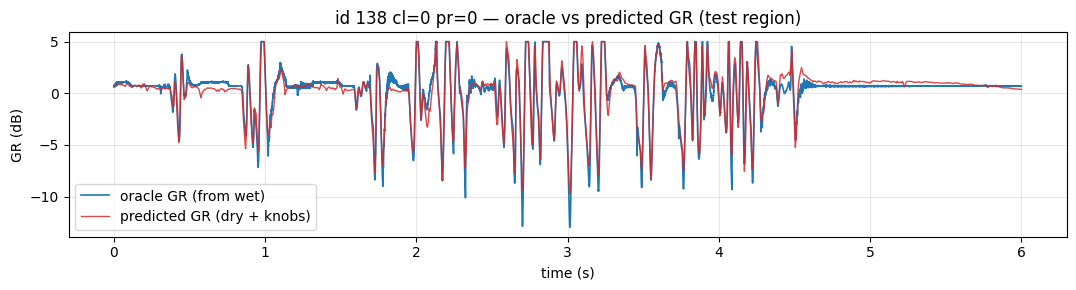

In [20]:
# ── 9a. Load the LA2A blackbox GR predictor (deployable GR source) ────
# BlackboxGRLSTM from la2a_gr_pred_runs (dry + 2 knobs → frame-rate GR in dB,
# hop 256), decoded / upsampled to a sample-rate GR curve with model.to_db().
# This is the DEPLOYABLE GR source (no wet audio needed), vs the oracle GR
# recomputed from (dry, wet). Trained with the SAME split policy / seed as this
# run, so its test regions are the ones scored below.

from model_blackbox_gr import BlackboxGRLSTM
from gr_target import GR_DB_MIN as _GR_MIN_05, GR_DB_MAX as _GR_MAX_05

# The predictor's output clamp must equal the clamp the coloration model applies
# to its GR input, or the cascade would silently rescale.
assert (_GR_MIN_05, _GR_MAX_05) == (GR_DB_MIN, GR_DB_MAX), (_GR_MIN_05, _GR_MAX_05)

GR_PRED_MODEL_TYPE = "la2a_blackbox_gr_lstm_film"
SELECTED_GR_PRED_RUN: str | None = None      # None = latest matching run

_gr_runs = list_runs(GR_PRED_RUNS_DIR)
assert not _gr_runs.empty, f"No runs in {GR_PRED_RUNS_DIR}"
_gr_runs = _gr_runs[_gr_runs["type"] == GR_PRED_MODEL_TYPE]
assert not _gr_runs.empty, (
    f"No '{GR_PRED_MODEL_TYPE}' runs in {GR_PRED_RUNS_DIR} — train with "
    "train_lstm_blackbox_gr.ipynb first, or drop 'predicted' from ABLATION_VARIANTS."
)
GR_PRED_RUN = SELECTED_GR_PRED_RUN or str(_gr_runs.iloc[-1]["run"])
_gp_dir = os.path.join(GR_PRED_RUNS_DIR, GR_PRED_RUN)

with open(os.path.join(_gp_dir, "hparams.json")) as f:
    GR_PRED_HP = json.load(f)
_gpm = GR_PRED_HP["model"]
assert tuple(GR_PRED_HP["gr_range_db"]) == (GR_DB_MIN, GR_DB_MAX), GR_PRED_HP["gr_range_db"]
assert int(GR_PRED_HP["sample_rate"]) == SR, GR_PRED_HP["sample_rate"]

GR_PRED_MODEL = BlackboxGRLSTM(
    hop_size=int(GR_PRED_HP["hop_size"]),
    sample_rate=int(GR_PRED_HP["sample_rate"]),
    enc_channels=int(_gpm["enc_channels"]),
    frontend_channels=int(_gpm["frontend_channels"]),
    temporal_kernel=int(_gpm["temporal_kernel"]),
    temporal_dilations=tuple(int(d) for d in _gpm["temporal_dilations"]),
    hidden_size=int(_gpm["hidden_size"]),
    num_controls=int(_gpm["num_controls"]),
    film_order=int(_gpm["film_order"]),
)
GR_PRED_CKPT = latest_best_checkpoint(_gp_dir)
_gp_sd = torch.load(GR_PRED_CKPT, map_location=DEVICE, weights_only=False)["state_dict"]
GR_PRED_MODEL.load_state_dict(
    {k[len("model."):]: v for k, v in _gp_sd.items() if k.startswith("model.")})
GR_PRED_MODEL.to(DEVICE).eval()
GR_HOP = int(GR_PRED_HP["hop_size"])
print(f"GR predictor: {sum(p.numel() for p in GR_PRED_MODEL.parameters()):,} params "
      f"({GR_PRED_RUN} / {os.path.basename(GR_PRED_CKPT)}, hop={GR_HOP})")


@torch.no_grad()
def predict_gr_buffer(dry_b: torch.Tensor, params: torch.Tensor) -> torch.Tensor:
    """Sample-rate GR (dB) predicted from dry + knobs, for a whole region buffer.

    One forward over the buffer: the frame encoder is hop-aligned and the state
    cold-starts at the buffer start (zero frame-context == silence), so this is
    exactly what a chunked stream over the same buffer would produce. The buffer
    already begins with the warm-up region, which doubles as the predictor's
    context. A sub-frame tail is padded with the last value.
    """
    N = dry_b.shape[-1]
    L = (N // GR_HOP) * GR_HOP
    if L == 0:
        return torch.zeros_like(dry_b)
    gr_fr = GR_PRED_MODEL(dry_b[..., :L].unsqueeze(0).to(DEVICE), params)
    gr = GR_PRED_MODEL.to_db(gr_fr, sample_len=L).squeeze(0).cpu()   # [1, L] dB, clamped
    if gr.shape[-1] < N:
        gr = torch.cat([gr, gr[..., -1:].expand(1, N - gr.shape[-1])], dim=-1)
    return gr


# ── sanity: predicted vs oracle GR on the first recording's TEST region ──
_sr_rec = EVAL_RECS[0]
_sd, _sg, _sw, _swarm = _region_buffer(_sr_rec, "test")
_sg_hat = predict_gr_buffer(_sd, _params_for(_sr_rec))
_mae = float((_sg_hat[..., _swarm:].clamp(GR_DB_MIN, GR_DB_MAX)
              - _sg[..., _swarm:].clamp(GR_DB_MIN, GR_DB_MAX)).abs().mean())
print(f"predictor GR MAE vs oracle — id {_sr_rec['id']} cl={_sr_rec['comp_limit']} "
      f"pr={_sr_rec['peak_reduction']} (scored part): {_mae:.3f} dB")

_a = _swarm
_b = min(_swarm + int(6 * SR), _sd.shape[-1])
_t = np.arange(_b - _a) / SR
plt.figure(figsize=(11, 3))
plt.plot(_t, _sg[0, _a:_b].clamp(GR_DB_MIN, GR_DB_MAX).numpy(), lw=1.2,
         label="oracle GR (from wet)", color="#1f77b4")
plt.plot(_t, _sg_hat[0, _a:_b].numpy(), lw=1.0, label="predicted GR (dry + knobs)",
         color="#d62728", alpha=0.85)
plt.xlabel("time (s)"); plt.ylabel("GR (dB)"); plt.grid(alpha=0.3); plt.legend()
plt.title(f"id {_sr_rec['id']} cl={_sr_rec['comp_limit']} pr={_sr_rec['peak_reduction']} "
          f"— oracle vs predicted GR (test region)")
plt.tight_layout(); plt.show()
del _sd, _sg, _sw, _sg_hat

In [21]:
# ── 9b. Run the GR-source ablation (few test regions, same ckpt) ─────
# Streams the SAME ColorBlackboxLSTM checkpoint with different GR sources through
# the SAME 9-column engine, plus the model-bypassed amp_match baseline. No
# training anywhere. Simplified: only ABLATION_RECS (a spread of peak-reduction
# settings) instead of the full split — enough to read the variant ordering.

ABLATION_VARIANTS = ["oracle", "predicted", "const_mean", "const_0db", "amp_match"]
# a spread of settings (first available at comp_limit=0, pr in 0/50/100)
_abl_targets = [(0, 0), (0, 50), (0, 100)]
ABLATION_RECS = []
for cl, pr in _abl_targets:
    cand = [r for r in EVAL_RECS if r["comp_limit"] == cl and r["peak_reduction"] == pr]
    if cand:
        ABLATION_RECS.append(cand[0])
ABLATION_RECS = ABLATION_RECS or EVAL_RECS[:3]


def _variant_gr(dry_b, gr_oracle, params, variant):
    if variant in ("oracle", "amp_match"):
        return gr_oracle
    if variant == "predicted":
        return predict_gr_buffer(dry_b, params)
    if variant == "const_mean":
        return torch.full_like(gr_oracle, float(gr_oracle.mean()))
    if variant == "const_0db":
        return torch.zeros_like(gr_oracle)
    raise ValueError(variant)


abl_chunk_rows = {v: [] for v in ABLATION_VARIANTS}
abl_pair_rows, _pred_gr_maes = [], []
for i, rec in enumerate(ABLATION_RECS, start=1):
    dry_b, gr_or, wet_b, warm = _region_buffer(rec, "test")
    params = _params_for(rec)
    for variant in ABLATION_VARIANTS:
        print(f"[{i}/{len(ABLATION_RECS)}] id {rec['id']} pr={rec['peak_reduction']} — {variant}")
        gr_used = _variant_gr(dry_b, gr_or, params, variant)
        if variant == "predicted":
            _pred_gr_maes.append(float(
                (gr_used[..., warm:].clamp(GR_DB_MIN, GR_DB_MAX)
                 - gr_or[..., warm:].clamp(GR_DB_MIN, GR_DB_MAX)).abs().mean()))
        rows = _stream_buffer(dry_b, gr_used, wet_b, warm, params,
                              bypass=(variant == "amp_match"))
        abl_chunk_rows[variant] += rows
        abl_pair_rows.append({
            "Variant": variant, "Id": rec["id"], "comp_limit": rec["comp_limit"],
            "peak_reduction": rec["peak_reduction"],
            "Frames": sum(r["Frames"] for r in rows),
            **_weighted_average_metric_rows(rows, METRIC_COLS)})
    gc.collect()

if _pred_gr_maes:
    print(f"\npredictor GR MAE vs oracle over {len(_pred_gr_maes)} test regions: "
          f"{np.mean(_pred_gr_maes):.3f} dB")

abl_split_df = pd.DataFrame([
    {"Variant": v, "Recordings": len(ABLATION_RECS),
     "Duration (s)": sum(r["Frames"] for r in abl_chunk_rows[v]) / sr,
     **_weighted_average_metric_rows(abl_chunk_rows[v], METRIC_COLS)}
    for v in ABLATION_VARIANTS
])
abl_pair_df = pd.DataFrame(abl_pair_rows)

abl_pair_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation_pairs.csv", index=False)
abl_split_df.to_csv(Path(RUN_DIR) / "eval_audio_metrics_gr_ablation.csv", index=False)
print(f"Saved -> {RUN_DIR}/eval_audio_metrics_gr_ablation(.csv, _pairs.csv)")

display(abl_split_df)
display(abl_pair_df)

[1/3] id 138 pr=0 — oracle
[1/3] id 138 pr=0 — predicted
[1/3] id 138 pr=0 — const_mean
[1/3] id 138 pr=0 — const_0db
[1/3] id 138 pr=0 — amp_match
[2/3] id 148 pr=50 — oracle
[2/3] id 148 pr=50 — predicted
[2/3] id 148 pr=50 — const_mean
[2/3] id 148 pr=50 — const_0db
[2/3] id 148 pr=50 — amp_match
[3/3] id 158 pr=100 — oracle
[3/3] id 158 pr=100 — predicted
[3/3] id 158 pr=100 — const_mean
[3/3] id 158 pr=100 — const_0db
[3/3] id 158 pr=100 — amp_match

predictor GR MAE vs oracle over 3 test regions: 0.783 dB
Saved -> /Volumes/Saola's Drive/AllCode/thesis/data/la2a_gain_prior_runs/la2a_color_bb_20260730_134114_la2a_lstm32_color_bb_b64lr2e3/eval_audio_metrics_gr_ablation(.csv, _pairs.csv)


,Variant,Recordings,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,oracle,3,89.991837,0.277066,0.067710,0.464884,0.024200,0.006284,0.000412,0.033461,0.046596,0.116378
1,predicted,3,89.991837,0.881079,0.191785,0.556644,0.032739,0.009365,0.000477,0.117931,0.115755,0.162674
2,const_mean,3,89.991837,0.958218,0.173593,0.584440,0.036036,0.009757,0.000629,0.281593,0.116949,0.167073
3,const_0db,3,89.991837,3.584001,2.826827,1.322946,1.293770,0.022630,0.001515,0.396850,0.775976,0.790047
4,amp_match,3,89.991837,0.349049,0.113502,0.597029,0.027398,0.011837,0.001221,0.103466,0.089445,0.174005


,Variant,Id,comp_limit,peak_reduction,Frames,GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,oracle,138,0,0,1322880,0.099510,0.024188,0.320603,0.026062,0.008914,0.000819,0.020360,0.018896,0.074207
1,predicted,138,0,0,1322880,0.688223,0.152224,0.416255,0.032273,0.013964,0.000941,0.125705,0.089771,0.132396
2,const_mean,138,0,0,1322880,0.364835,0.094620,0.385352,0.027500,0.012276,0.001121,0.108101,0.064113,0.105218
3,const_0db,138,0,0,1322880,0.802771,0.173055,0.447652,0.031865,0.015845,0.001153,0.112859,0.099362,0.140740
4,amp_match,138,0,0,1322880,0.235868,0.072162,0.413329,0.023763,0.017647,0.002307,0.064878,0.064261,0.086068
5,oracle,148,0,50,1322880,0.127803,0.031533,0.336716,0.023450,0.007023,0.000387,0.019191,0.024021,0.075532
6,predicted,148,0,50,1322880,0.666828,0.149794,0.430189,0.029349,0.010553,0.000460,0.102649,0.090008,0.121550
7,const_mean,148,0,50,1322880,0.882316,0.179755,0.482339,0.034352,0.013177,0.000725,0.458047,0.111985,0.136791
8,const_0db,148,0,50,1322880,1.206203,0.446497,0.585703,0.072952,0.019823,0.001352,0.434931,0.230662,0.241723
9,amp_match,148,0,50,1322880,0.286296,0.088277,0.479839,0.018277,0.013309,0.001227,0.100815,0.076604,0.110400


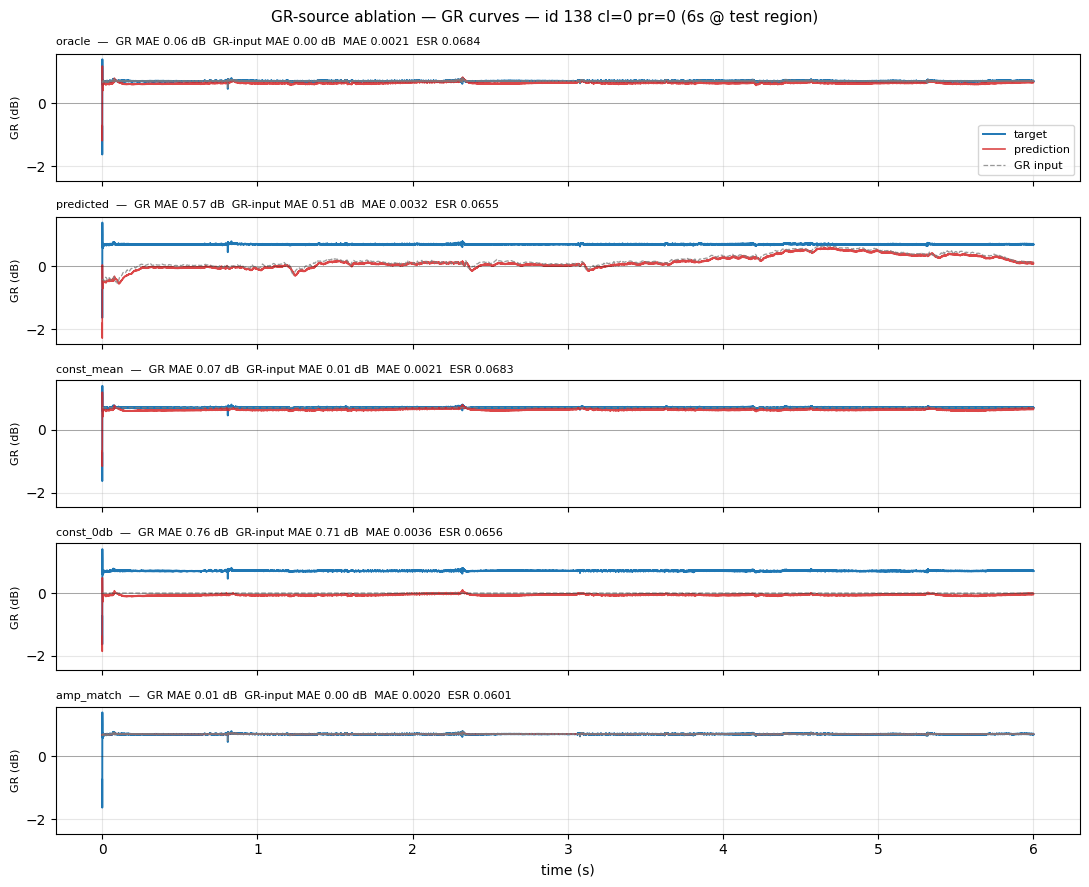

,variant,GR MAE (dB),GR-input MAE (dB),MAE,ESR
0,oracle,0.064730,0.000317,0.002135,0.068394
1,predicted,0.567139,0.505136,0.003164,0.065518
2,const_mean,0.067811,0.008176,0.002136,0.068289
3,const_0db,0.764715,0.705129,0.003585,0.065628
4,amp_match,0.006089,0.000317,0.001957,0.060132


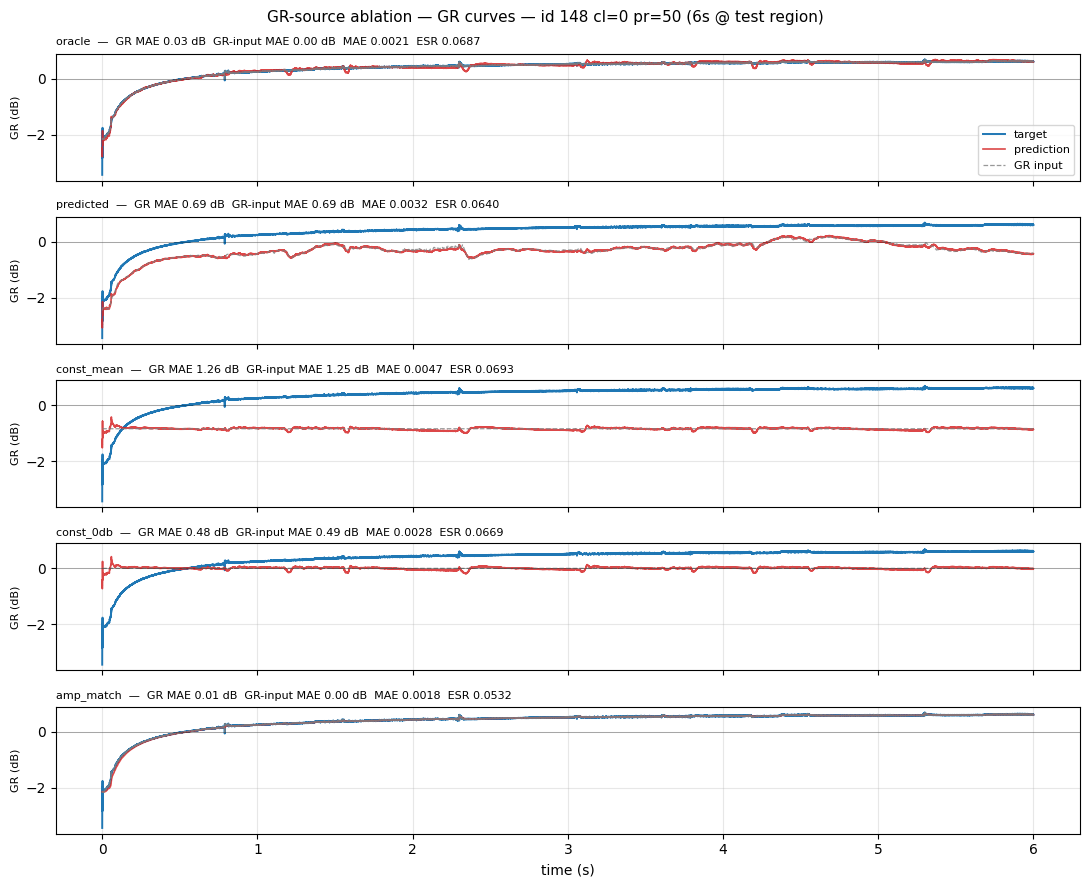

,variant,GR MAE (dB),GR-input MAE (dB),MAE,ESR
0,oracle,0.033751,0.000321,0.002062,0.068672
1,predicted,0.688526,0.688902,0.003197,0.063958
2,const_mean,1.255945,1.253489,0.004740,0.069336
3,const_0db,0.484711,0.485717,0.002790,0.066864
4,amp_match,0.011222,0.000321,0.001812,0.053174


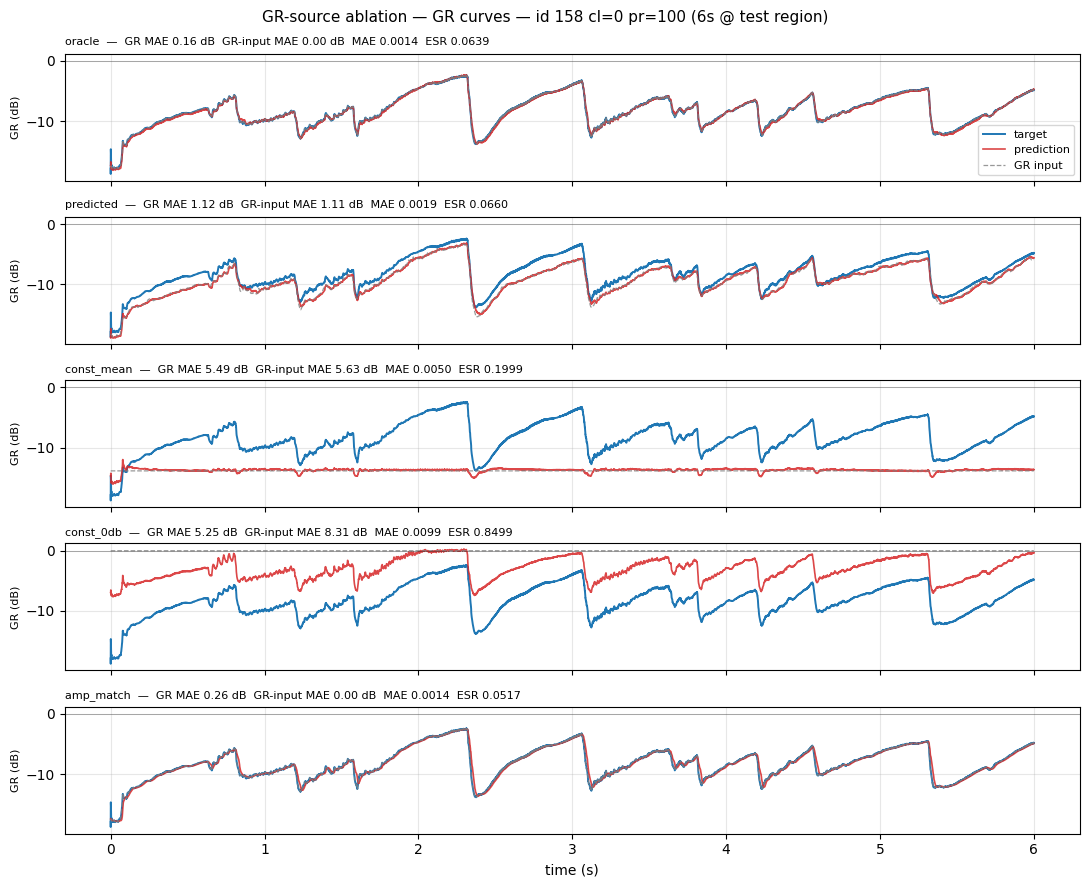

,variant,GR MAE (dB),GR-input MAE (dB),MAE,ESR
0,oracle,0.159232,0.001160,0.001384,0.063896
1,predicted,1.115093,1.105243,0.001937,0.065955
2,const_mean,5.485865,5.626132,0.005045,0.199870
3,const_0db,5.246945,8.309229,0.009927,0.849917
4,amp_match,0.261514,0.001160,0.001392,0.051747


In [22]:
# ── 9c. Ablation GR curves — per-variant GR trajectory (one segment) ─
# For each ablation recording, run the same 6 s test-region segment (10 s pre-roll
# after reset_states) once per GR source and plot the GR curves: target (from wet)
# vs prediction (recovered from the variant output) vs the GR actually fed (dashed).
# Because gain is an explicit multiply, "prediction" should track "GR input" almost
# exactly for every variant — that obedience is the property this model buys.

@torch.no_grad()
def predict_segment_variant(rec, start_sec, variant, duration_sec=6.0,
                            pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    start = int(round(start_sec * SR)); stop = start + int(round(duration_sec * SR))
    context_start = max(0, start - int(round(pre_roll_sec * SR)))
    offset = start - context_start
    dry_ctx, gr_or_ctx, wet_ctx = _read_seg_with_gr(rec, context_start, stop)
    params = _params_for(rec)
    gr_ctx = _variant_gr(dry_ctx, gr_or_ctx, params, variant)
    bypass = variant == "amp_match"

    if bypass:
        pred_full = amplitude_match(dry_ctx.unsqueeze(0), gr_ctx.unsqueeze(0))
    else:
        MODEL.reset_states()
        pred_full = MODEL(dry_ctx.unsqueeze(0).to(DEVICE), gr_ctx.unsqueeze(0).to(DEVICE), params)
    seg_len = min(stop - start, pred_full.shape[-1] - offset)
    sl = slice(offset, offset + seg_len)
    pred = pred_full[..., sl].squeeze(0).cpu()
    wet, dry = wet_ctx[..., sl].cpu(), dry_ctx[..., sl].cpu()
    gr_in = np.clip(gr_ctx[..., sl].squeeze().numpy(), GR_DB_MIN, GR_DB_MAX)
    err = (pred - wet).squeeze().numpy()
    gr_true, gr_pred = _gr_from_audio(dry, wet), _gr_from_audio(dry, pred)
    return {"variant": variant, "time": np.arange(pred.shape[-1]) / SR,
            "gr_in": gr_in, "gr_true": gr_true, "gr_pred": gr_pred,
            "mae": float(np.mean(np.abs(err))),
            "esr": float(esr_metric(wet.unsqueeze(0), pred.unsqueeze(0))),
            "gr_mae_db": float(np.mean(np.abs(gr_pred - gr_true))),
            "gr_in_mae_db": float(np.mean(np.abs(gr_in - gr_true)))}


def ablation_gr_sweep(rec, start_sec=None, duration_sec=6.0, pre_roll_sec=DEFAULT_PRE_ROLL_SEC):
    start_sec = _default_test_segment_sec(rec) if start_sec is None else start_sec
    segs = [predict_segment_variant(rec, start_sec, v, duration_sec, pre_roll_sec)
            for v in ABLATION_VARIANTS]

    fig, axes = plt.subplots(len(segs), 1, figsize=(11, 1.8 * len(segs)),
                             sharex=True, sharey=True, squeeze=False)
    for ax, s in zip(axes[:, 0], segs):
        ax.plot(s["time"], s["gr_true"], lw=1.4, color="#1f77b4", label="target")
        ax.plot(s["time"], s["gr_pred"], lw=1.2, color="#d62728", alpha=0.85, label="prediction")
        ax.plot(s["time"], s["gr_in"], lw=0.9, ls="--", color="#7f7f7f", alpha=0.8, label="GR input")
        ax.axhline(0, color="k", lw=0.5, alpha=0.4)
        ax.set_ylabel("GR (dB)", fontsize=8)
        ax.set_title(f"{s['variant']}  —  GR MAE {s['gr_mae_db']:.2f} dB  "
                     f"GR-input MAE {s['gr_in_mae_db']:.2f} dB  "
                     f"MAE {s['mae']:.4f}  ESR {s['esr']:.4f}", fontsize=8, loc="left")
        ax.grid(alpha=0.3)
    axes[0, 0].legend(loc="lower right", fontsize=8)
    axes[-1, 0].set_xlabel("time (s)")
    fig.suptitle(f"GR-source ablation — GR curves — id {rec['id']} "
                 f"cl={rec['comp_limit']} pr={rec['peak_reduction']} "
                 f"({duration_sec:.0f}s @ test region)", fontsize=11)
    plt.tight_layout(); plt.show()

    df = pd.DataFrame([
        {"variant": s["variant"], "GR MAE (dB)": s["gr_mae_db"],
         "GR-input MAE (dB)": s["gr_in_mae_db"], "MAE": s["mae"], "ESR": s["esr"]}
        for s in segs])
    display(df)
    return segs, df


abl_sweeps = {rec["id"]: ablation_gr_sweep(rec) for rec in ABLATION_RECS}

## 10. Summary — val → test, and what the trunk buys over the pure multiply

Two numbers this model exists to produce, read off the CSVs written above:

- **val → test gap** (── 7 / ── 8): both are unseen audio at known settings, so a
  small gap means the coloration trunk generalises across the corpus rather than
  memorising region-specific material.
- **oracle vs `amp_match` vs `predicted`** (§9): `amp_match` is the pure multiply
  with no network — the trained trunk must beat it on the colour-stage columns
  (MR-STFT, ESR (A-wt), M_SF) to justify itself. `predicted` is the deployable,
  wet-free number for the sidechain cascade.

In [23]:
# ── 10. val → test summary + the GR-source table ─────────────────────

def _split_row(fn):
    p = Path(RUN_DIR) / fn
    return pd.read_csv(p).iloc[0] if p.is_file() else None


_val = _split_row("eval_audio_metrics_validation.csv")
_test = _split_row("eval_audio_metrics_test.csv")

rows = []
for name, r in (("validation", _val), ("test", _test)):
    if r is not None:
        rows.append({"Split": name, **{c: float(r[c]) for c in METRIC_COLS if c in r},
                     "Duration (s)": float(r.get("Duration (s)", float("nan")))})
summary_df = pd.DataFrame(rows)
display(summary_df)

if _val is not None and _test is not None:
    for col in ("MR-STFT", "ESR (A-wt)", "GR MAE (dB)"):
        if col in _val and col in _test:
            v, t = float(_val[col]), float(_test[col])
            print(f"{col:<12} val={v:.4f}  test={t:.4f}  → val→test gap = {t - v:+.4f}")

_abl_path = Path(RUN_DIR) / "eval_audio_metrics_gr_ablation.csv"
if _abl_path.is_file():
    print("\nGR-source ablation (test regions, same checkpoint):")
    _abl = pd.read_csv(_abl_path)
    display(_abl[["Variant", "Duration (s)"] + [c for c in METRIC_COLS if c in _abl.columns]])
    if {"oracle", "amp_match"} <= set(_abl["Variant"]):
        _o = _abl.set_index("Variant").loc["oracle"]
        _a = _abl.set_index("Variant").loc["amp_match"]
        for col in ("MR-STFT", "ESR (A-wt)"):
            if col in _abl.columns:
                print(f"{col:<12} amp_match={float(_a[col]):.4f} → oracle={float(_o[col]):.4f}  "
                      f"({100 * (float(_a[col]) - float(_o[col])) / max(float(_a[col]), 1e-12):+.1f}% "
                      f"from the coloration trunk)")
    if "predicted" in set(_abl["Variant"]):
        _o = _abl.set_index("Variant").loc["oracle"]
        _p = _abl.set_index("Variant").loc["predicted"]
        for col in ("MR-STFT", "ESR (A-wt)", "GR MAE (dB)"):
            if col in _abl.columns:
                print(f"{col:<12} oracle={float(_o[col]):.4f} → predicted={float(_p[col]):.4f}  "
                      f"(deployment gap {float(_p[col]) - float(_o[col]):+.4f})")

,Split,GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF,Duration (s)
0,validation,0.391672,0.072489,0.616440,0.030917,0.012240,0.001506,0.034261,0.050843,0.137826,2513.77415
1,test,0.437502,0.082284,0.555358,0.038639,0.013964,0.001641,0.040246,0.060300,0.154705,2513.77415


MR-STFT      val=0.6164  test=0.5554  → val→test gap = -0.0611
ESR (A-wt)   val=0.0309  test=0.0386  → val→test gap = +0.0077
GR MAE (dB)  val=0.3917  test=0.4375  → val→test gap = +0.0458

GR-source ablation (test regions, same checkpoint):


,Variant,Duration (s),GR MAE (dB),MR-STE,MR-STFT,ESR (A-wt),MAE (L1),MSE (L2),EDC,M_NRMSE,M_SF
0,oracle,89.991837,0.277066,0.067710,0.464884,0.024200,0.006284,0.000412,0.033461,0.046596,0.116378
1,predicted,89.991837,0.881079,0.191785,0.556644,0.032739,0.009365,0.000477,0.117931,0.115755,0.162674
2,const_mean,89.991837,0.958218,0.173593,0.584440,0.036036,0.009757,0.000629,0.281593,0.116949,0.167073
3,const_0db,89.991837,3.584001,2.826827,1.322946,1.293770,0.022630,0.001515,0.396850,0.775976,0.790047
4,amp_match,89.991837,0.349049,0.113502,0.597029,0.027398,0.011837,0.001221,0.103466,0.089445,0.174005


MR-STFT      amp_match=0.5970 → oracle=0.4649  (+22.1% from the coloration trunk)
ESR (A-wt)   amp_match=0.0274 → oracle=0.0242  (+11.7% from the coloration trunk)
MR-STFT      oracle=0.4649 → predicted=0.5566  (deployment gap +0.0918)
ESR (A-wt)   oracle=0.0242 → predicted=0.0327  (deployment gap +0.0085)
GR MAE (dB)  oracle=0.2771 → predicted=0.8811  (deployment gap +0.6040)
